# REQUERIMIENTO TÉCNICO: VALIDACIÓN ESTADÍSTICA - ESTRATEGIA "GAP STRETCH REVERSION"

## 1. OBJETIVO
Validar la ventaja estadística de la anomalía de "Agotamiento de Rango contra Gap" en el Nasdaq (NQ). El objetivo es cuantificar el Profit Factor y la Expectancia de la reversión a la media (VWAP/Open) tras un estiramiento extremo (Stretch) de 0.75 ATR.

## 2. ORIGEN DE DATOS
- **Ruta:** `/home/quant/data/processed/nq_1m_continuous.parquet`
- **Asset:** NQ (Futuros Nasdaq 100)
- **Timeframe:** 1 minuto (OHLCV).

## 3. LÓGICA DE PROCESAMIENTO (CAPA 1)
El script debe realizar las siguientes transformaciones por sesión RTH (09:30 - 16:00 NY):

### A. Parámetros de Escenario
1. **ATR_14_RTH:** Calcular el ATR de 14 días usando únicamente los rangos de la sesión RTH (High_RTH - Low_RTH).
2. **Gap de Apertura:** $Gap = Open_{09:30} - Close_{anterior}$.
3. **Filtro de Relevancia:** Solo procesar días donde $|Gap| > 0.25 \times ATR\_14\_RTH$.

### B. Segmentación de Trades (Independientes)
El análisis debe separar los resultados en dos dataframes distintos:

**Escenario LONG (Reversión tras Gap Down):**
- **Condición:** $Gap < -0.25 \times ATR\_14\_RTH$.
- **Trigger:** El precio debe subir y tocar el nivel $Nivel\_Short = Open_{09:30} + (0.75 \times ATR\_14\_RTH)$.
- **Entrada Virtual:** Short (Venta) en el nivel exacto de $Nivel\_Short$.

**Escenario SHORT (Reversión tras Gap Up):**
- **Condición:** $Gap > 0.25 \times ATR\_14\_RTH$.
- **Trigger:** El precio debe caer y tocar el nivel $Nivel\_Long = Open_{09:30} - (0.75 \times ATR\_14\_RTH)$.
- **Entrada Virtual:** Long (Compra) en el nivel exacto de $Nivel\_Long$.

## 4. GESTIÓN DE SALIDA (BACKTEST BASELINE)
Para esta validación, aplicar reglas fijas:
- **Stop Loss:** Entrada $\pm (0.25 \times ATR\_14\_RTH)$.
- **Take Profit:** El nivel de $VWAP$ de la sesión en el momento de tocar el trigger o el $Open$ (el que ofrezca mejor R).
- **Time Exit:** Si a las 15:59 la posición sigue abierta, cerrar a mercado.

## 5. MÉTRICAS REQUERIDAS (OUTPUT)
Generar una tabla comparativa para **Longs** y **Shorts** con:
1. Nº de Trades totales.
2. Profit Factor.
3. Win Rate (%).
4. Esperanza Matemática (en múltiplos de R).
5. Máximo Drawdown (en R).
6. Correlación de señales con la estrategia ORB (si es posible integrar las fechas de ORB).

---
**Nota para el Desarrollador:** Priorizar la vectorización en Pandas para el cálculo del ATR y los niveles. No generar código de visualización complejo hasta que la tabla de métricas base sea validada.

In [5]:
import pandas as pd

# Definición de ruta según requerimiento técnico
path = "/home/quant/data/processed/nq_1m_continuous.parquet"

def check_dataset(file_path):
    try:
        # Carga del dataset
        df = pd.read_parquet(file_path)
        
        # Mostrar encabezados y primeras filas
        print("--- ESTRUCTURA DEL DATASET (HEAD) ---")
        print(df.head())
        
        print("\n--- INFORMACIÓN DE COLUMNAS Y TIPOS ---")
        print(df.info())
        
        # Verificar si el índice es datetime o si existe una columna de tiempo
        if not pd.api.types.is_datetime64_any_dtype(df.index):
            print("\n⚠️ Alerta: El índice no es datetime. Se verificará conversión.")
        
        return df
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        return None

# Ejecución
df_check = check_dataset(path)

--- ESTRUCTURA DEL DATASET (HEAD) ---
                        Open     High      Low    Close  Volume Ticker
timestamp                                                             
2010-06-06 18:00:00  1831.75  1831.75  1828.75  1829.00     117   NQM0
2010-06-06 18:01:00  1828.50  1831.00  1828.50  1830.50      99   NQM0
2010-06-06 18:02:00  1830.50  1832.25  1830.50  1831.25      32   NQM0
2010-06-06 18:03:00  1830.50  1831.50  1830.50  1830.50      12   NQM0
2010-06-06 18:04:00  1830.50  1830.50  1830.50  1830.50       1   NQM0

--- INFORMACIÓN DE COLUMNAS Y TIPOS ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5249651 entries, 2010-06-06 18:00:00 to 2025-12-12 16:59:00
Data columns (total 6 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Open    float64
 1   High    float64
 2   Low     float64
 3   Close   float64
 4   Volume  int64  
 5   Ticker  object 
dtypes: float64(4), int64(1), object(1)
memory usage: 280.4+ MB
None


In [6]:
import pandas as pd
import numpy as np

# --- CONFIGURACIÓN Y RUTAS ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
APP_ID = "gap-stretch-v1"

def run_gap_stretch_validation(file_path):
    # 1. Carga de Datos
    df = pd.read_parquet(file_path)
    
    # 2. Resampling para obtener métricas RTH (09:30 - 16:00)
    # Filtramos solo el horario regular para el cálculo del ATR
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Cálculo de High y Low diario de la sesión RTH
    daily_rth = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max',
        'Low': 'min',
        'Open': 'first',
        'Close': 'last'
    })
    
    # 3. Cálculo de ATR_14_RTH (Basado en rango High-Low de sesión)
    daily_rth['Range'] = daily_rth['High'] - daily_rth['Low']
    daily_rth['ATR_14'] = daily_rth['Range'].rolling(window=14).mean().shift(1)
    
    # 4. Cálculo del Gap
    daily_rth['Prev_Close'] = daily_rth['Close'].shift(1)
    daily_rth['Gap'] = daily_rth['Open'] - daily_rth['Prev_Close']
    
    # 5. Identificación de Escenarios (Filtro de Relevancia: |Gap| > 0.25 * ATR)
    daily_rth['Gap_Filter'] = 0.25 * daily_rth['ATR_14']
    daily_rth['Is_Relevant'] = daily_rth['Gap'].abs() > daily_rth['Gap_Filter']
    
    # 6. Definición de Niveles Operativos
    daily_rth['Level_Short'] = daily_rth['Open'] + (0.75 * daily_rth['ATR_14'])
    daily_rth['Level_Long'] = daily_rth['Open'] - (0.75 * daily_rth['ATR_14'])
    daily_rth['SL_Dist'] = 0.25 * daily_rth['ATR_14']
    
    # 7. Motor de Simulación (Capa 1)
    results = []
    
    relevant_days = daily_rth[daily_rth['Is_Relevant'] & daily_rth['ATR_14'].notna()].index
    
    for day in relevant_days:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_rth.loc[day]
        
        # Calcular VWAP acumulado para el día
        v_sum = (day_data['Close'] * day_data['Volume']).cumsum()
        vol_sum = day_data['Volume'].cumsum()
        day_data['VWAP'] = v_sum / vol_sum
        
        is_gap_up = day_meta['Gap'] > 0
        side = 'SHORT' if is_gap_up else 'LONG'
        trigger_level = day_meta['Level_Long'] if side == 'LONG' else day_meta['Level_Short']
        
        # Buscar el momento en que el precio toca el trigger
        # Para LONG: Low <= Level_Long | Para SHORT: High >= Level_Short
        if side == 'LONG':
            trigger_hits = day_data[day_data['Low'] <= trigger_level]
        else:
            trigger_hits = day_data[day_data['High'] >= trigger_level]
            
        if not trigger_hits.empty:
            entry_time = trigger_hits.index[0]
            entry_price = trigger_level
            
            # Gestión de salida: SL, TP (VWAP u Open), o Time Exit
            sl_price = entry_price - day_meta['SL_Dist'] if side == 'LONG' else entry_price + day_meta['SL_Dist']
            
            # El TP es dinámico al momento de la entrada
            vwap_at_entry = day_data.loc[entry_time, 'VWAP']
            open_price = day_meta['Open']
            
            # TP = Nivel que ofrezca mejor R (más alejado de la entrada en dirección del trade)
            if side == 'LONG':
                tp_price = max(vwap_at_entry, open_price)
            else:
                tp_price = min(vwap_at_entry, open_price)
            
            # Recorrer velas post-entrada
            post_entry = day_data.loc[entry_time:]
            
            trade_exit_price = None
            trade_type = ""
            
            for t, row in post_entry.iterrows():
                # 1. Chequeo de Stop Loss
                if (side == 'LONG' and row['Low'] <= sl_price) or (side == 'SHORT' and row['High'] >= sl_price):
                    trade_exit_price = sl_price
                    trade_type = "SL"
                    break
                # 2. Chequeo de Take Profit
                if (side == 'LONG' and row['High'] >= tp_price) or (side == 'SHORT' and row['Low'] <= tp_price):
                    trade_exit_price = tp_price
                    trade_type = "TP"
                    break
                # 3. Time Exit (15:59)
                if t.time() >= pd.Timestamp("15:59").time():
                    trade_exit_price = row['Close']
                    trade_type = "TIME"
                    break
            
            if trade_exit_price:
                # Cálculo de PnL en múltiplos de R
                risk = day_meta['SL_Dist']
                pnl_points = (trade_exit_price - entry_price) if side == 'LONG' else (entry_price - trade_exit_price)
                pnl_r = pnl_points / risk
                
                results.append({
                    'Date': day,
                    'Side': side,
                    'Entry': entry_price,
                    'Exit': trade_exit_price,
                    'Type': trade_type,
                    'PnL_R': pnl_r
                })

    return pd.DataFrame(results)

def calculate_metrics(df_results):
    summary = []
    for side in ['LONG', 'SHORT']:
        subset = df_results[df_results['Side'] == side]
        if subset.empty: continue
        
        trades = len(subset)
        wins = len(subset[subset['PnL_R'] > 0])
        wr = (wins / trades) * 100
        
        gross_profit = subset[subset['PnL_R'] > 0]['PnL_R'].sum()
        gross_loss = abs(subset[subset['PnL_R'] < 0]['PnL_R'].sum())
        pf = gross_profit / gross_loss if gross_loss != 0 else np.inf
        
        expectancy = subset['PnL_R'].mean()
        
        # Drawdown en R
        cum_r = subset['PnL_R'].cumsum()
        peak = cum_r.cummax()
        dd = cum_r - peak
        mdd = dd.min()
        
        summary.append({
            'Escenario': side,
            'Nº Trades': trades,
            'Profit Factor': round(pf, 2),
            'Win Rate (%)': round(wr, 2),
            'Esperanza (R)': round(expectancy, 2),
            'Max DD (R)': round(mdd, 2)
        })
    
    return pd.DataFrame(summary)

# --- EJECUCIÓN ---
df_trades = run_gap_stretch_validation(PATH)
metrics_table = calculate_metrics(df_trades)

print("\n--- RESULTADOS ESTRATEGIA GAP STRETCH REVERSION ---")
print(metrics_table.to_string(index=False))


--- RESULTADOS ESTRATEGIA GAP STRETCH REVERSION ---
Escenario  Nº Trades  Profit Factor  Win Rate (%)  Esperanza (R)  Max DD (R)
     LONG        254           0.88         30.71          -0.08      -36.41
    SHORT        262           0.66         37.40          -0.17      -47.53


In [8]:
# REQUERIMIENTO TÉCNICO: ANÁLISIS DE EXCURSIÓN ADVERSA Y PROBABILIDAD DE RETORNO

## 1. OBJETIVO
Determinar la viabilidad de la reversión tras un movimiento de 0.75 ATR contra el Gap, analizando niveles de retorno y profundidad del exceso (Excursión Adversa).

## 2. UNIVERSO DE ESTUDIO
- Días con $|Gap| > 0.25 \times ATR\_14\_RTH$.
- Días donde el precio cruza el $Open$ y alcanza una distancia de $\pm 0.75 \times ATR\_14\_RTH$ desde el $Open$.

## 3. MÉTRICAS DE RETORNO (FRECUENCIA)
Para el conjunto de días que cumplen el universo de estudio, calcular:
1. **% Retorno al Open:** Probabilidad de que el precio, tras tocar el 0.75 ATR, toque nuevamente el precio de apertura ($Open$) antes de las 16:00.
2. **% Retorno al VWAP:** Probabilidad de que el precio toque el $VWAP$ intradía (acumulado) tras haber tocado el 0.75 ATR.

## 4. ANÁLISIS DE EXCURSIÓN ADVERSA (STRETCH)
Medir cuánto más se aleja el precio desde el $Open$ una vez validado el escenario (medido en unidades de ATR_14):
1. **MAE (Maximum Adverse Excursion):** Valor máximo alcanzado en la dirección del stretch tras tocar el 0.75 ATR.
2. **Media del Exceso:** Promedio de (Máximo_Día - 0.75 ATR) para determinar si el "elástico" suele estirarse hasta 1.0, 1.25, etc.
3. **Desviación Estándar del Exceso:** Para definir la ubicación lógica del Stop Loss.

## 5. ANÁLISIS TEMPORAL
1. **Hora del "Peak":** Registrar la hora exacta (HH:MM) en la que el precio alcanzó su punto más alejado del Open.
2. **Histograma de Frecuencia:** Distribución horaria de los puntos de máxima excursión.

## 6. OUTPUT REQUERIDO
- Tabla resumen con las métricas del punto 3 y 4.
- Histograma de horas del punto más alejado.
- Scatter plot: Eje X (Magnitud del Gap), Eje Y (Máxima Excursión post-0.75 ATR).

SyntaxError: invalid syntax (3101983392.py, line 4)

# REQUERIMIENTO TÉCNICO: ANÁLISIS DE EXCURSIÓN ADVERSA Y PROBABILIDAD DE RETORNO

## 1. OBJETIVO
Determinar la viabilidad de la reversión tras un movimiento de 0.75 ATR contra el Gap, analizando niveles de retorno y profundidad del exceso (Excursión Adversa).

## 2. UNIVERSO DE ESTUDIO
- Días con $|Gap| > 0.25 \times ATR\_14\_RTH$.
- Días donde el precio cruza el $Open$ y alcanza una distancia de $\pm 0.75 \times ATR\_14\_RTH$ desde el $Open$.

## 3. MÉTRICAS DE RETORNO (FRECUENCIA)
Para el conjunto de días que cumplen el universo de estudio, calcular:
1. **% Retorno al Open:** Probabilidad de que el precio, tras tocar el 0.75 ATR, toque nuevamente el precio de apertura ($Open$) antes de las 16:00.
2. **% Retorno al VWAP:** Probabilidad de que el precio toque el $VWAP$ intradía (acumulado) tras haber tocado el 0.75 ATR.

## 4. ANÁLISIS DE EXCURSIÓN ADVERSA (STRETCH)
Medir cuánto más se aleja el precio desde el $Open$ una vez validado el escenario (medido en unidades de ATR_14):
1. **MAE (Maximum Adverse Excursion):** Valor máximo alcanzado en la dirección del stretch tras tocar el 0.75 ATR.
2. **Media del Exceso:** Promedio de (Máximo_Día - 0.75 ATR) para determinar si el "elástico" suele estirarse hasta 1.0, 1.25, etc.
3. **Desviación Estándar del Exceso:** Para definir la ubicación lógica del Stop Loss.

## 5. ANÁLISIS TEMPORAL
1. **Hora del "Peak":** Registrar la hora exacta (HH:MM) en la que el precio alcanzó su punto más alejado del Open.
2. **Histograma de Frecuencia:** Distribución horaria de los puntos de máxima excursión.

## 6. OUTPUT REQUERIDO
- Tabla resumen con las métricas del punto 3 y 4.
- Histograma de horas del punto más alejado.
- Scatter plot: Eje X (Magnitud del Gap), Eje Y (Máxima Excursión post-0.75 ATR).

--- MÉTRICAS DE RETORNO Y EXCURSIÓN ---
                               Valor
Prob. Retorno al Open (%)     12.934
Prob. Retorno al VWAP (%)     44.788
MAE Promedio post-0.75 (ATR)   0.417
Exceso Total Medio (ATR)       1.167
Std Dev Exceso (ATR)           0.412


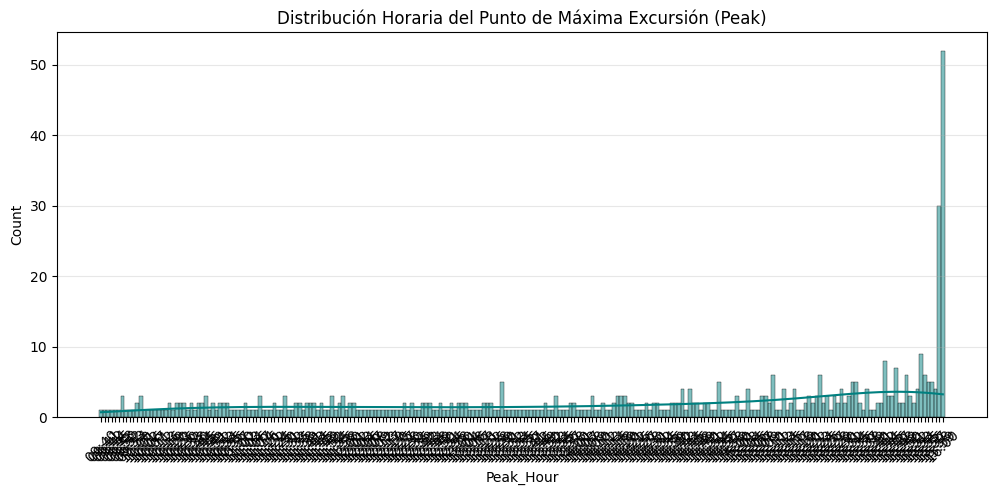

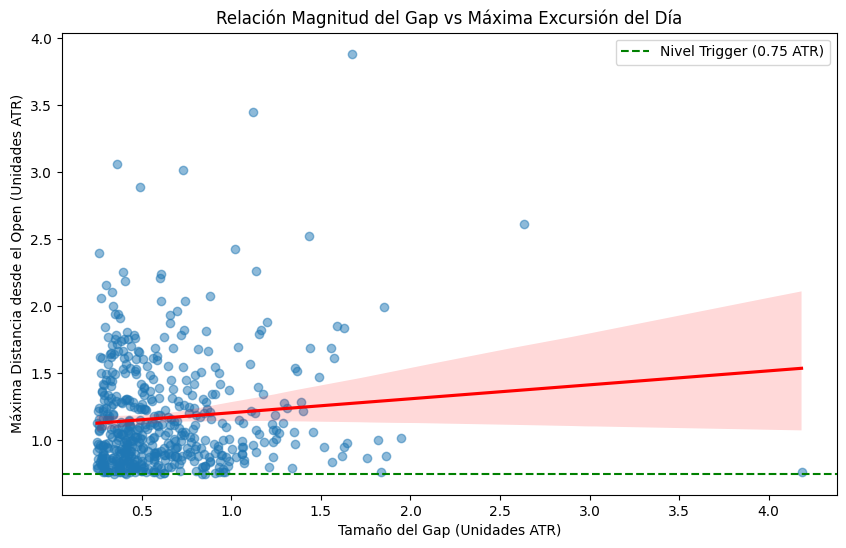

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# --- CONFIGURACIÓN ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"

def run_advanced_stretch_analysis(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    # Filtro Universo: |Gap| > 0.25 ATR
    daily['Gap_Filter'] = 0.25 * daily['ATR_14']
    daily_valid = daily[daily['Gap'].abs() > daily['Gap_Filter']].copy()
    
    analysis_results = []
    
    for day in daily_valid.index:
        if pd.isna(daily_valid.loc[day, 'ATR_14']): continue
        
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # VWAP Acumulado
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        
        is_gap_up = day_meta['Gap'] > 0
        trigger_level = open_p - (0.75 * atr) if not is_gap_up else open_p + (0.75 * atr)
        side = 'LONG_REVERSION' if not is_gap_up else 'SHORT_REVERSION'
        
        # Buscar Trigger
        if not is_gap_up: # Gap Down -> Buscamos Low <= Open - 0.75ATR para comprar reversión
            trigger_hits = day_data[day_data['Low'] <= trigger_level]
        else: # Gap Up -> Buscamos High >= Open + 0.75ATR para vender reversión
            trigger_hits = day_data[day_data['High'] >= trigger_level]
            
        if not trigger_hits.empty:
            t_entry = trigger_hits.index[0]
            post_trigger = day_data.loc[t_entry:]
            
            # 1. Análisis de Excursión (MAE)
            if not is_gap_up:
                max_extension = post_trigger['Low'].min()
                mae_points = trigger_level - max_extension # Cuánto más cayó
                peak_time = post_trigger['Low'].idxmin()
            else:
                max_extension = post_trigger['High'].max()
                mae_points = max_extension - trigger_level # Cuánto más subió
                peak_time = post_trigger['High'].idxmax()
                
            # 2. Probabilidades de Retorno
            # ¿Tocó el Open después del trigger?
            if not is_gap_up:
                hit_open = (post_trigger['High'] >= open_p).any()
            else:
                hit_open = (post_trigger['Low'] <= open_p).any()
                
            # ¿Tocó el VWAP después del trigger?
            # Nota: VWAP es dinámico, comparamos cada vela post-trigger
            if not is_gap_up:
                hit_vwap = (post_trigger['High'] >= post_trigger['VWAP']).any()
            else:
                hit_vwap = (post_trigger['Low'] <= post_trigger['VWAP']).any()
            
            analysis_results.append({
                'Date': day,
                'Gap_Mag_ATR': abs(day_meta['Gap'] / atr),
                'Side': side,
                'MAE_ATR': mae_points / atr,
                'Exceso_Total_ATR': (abs(max_extension - open_p)) / atr,
                'Hit_Open': hit_open,
                'Hit_VWAP': hit_vwap,
                'Peak_Hour': peak_time.strftime('%H:%M')
            })

    return pd.DataFrame(analysis_results)

# --- PROCESAMIENTO ---
df_analisis = run_advanced_stretch_analysis(PATH)

# --- GENERACIÓN DE OUTPUTS ---

# 1. Tabla de Métricas
metricas = {
    'Prob. Retorno al Open (%)': [df_analisis['Hit_Open'].mean() * 100],
    'Prob. Retorno al VWAP (%)': [df_analisis['Hit_VWAP'].mean() * 100],
    'MAE Promedio post-0.75 (ATR)': [df_analisis['MAE_ATR'].mean()],
    'Exceso Total Medio (ATR)': [df_analisis['Exceso_Total_ATR'].mean()],
    'Std Dev Exceso (ATR)': [df_analisis['Exceso_Total_ATR'].std()]
}
df_metrics = pd.DataFrame(metricas).T.rename(columns={0: 'Valor'})

print("--- MÉTRICAS DE RETORNO Y EXCURSIÓN ---")
print(df_metrics.round(3))

# 2. Visualización (Histograma de Horas Peak)
plt.figure(figsize=(12, 5))
df_analisis['Peak_Hour_DT'] = pd.to_datetime(df_analisis['Peak_Hour'], format='%H:%M')
df_analisis = df_analisis.sort_values('Peak_Hour_DT')
sns.histplot(data=df_analisis, x='Peak_Hour', bins=20, kde=True, color='teal')
plt.title("Distribución Horaria del Punto de Máxima Excursión (Peak)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. Scatter Plot: Gap vs Excursión
plt.figure(figsize=(10, 6))
sns.regplot(data=df_analisis, x='Gap_Mag_ATR', y='Exceso_Total_ATR', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.axhline(0.75, color='green', linestyle='--', label='Nivel Trigger (0.75 ATR)')
plt.title("Relación Magnitud del Gap vs Máxima Excursión del Día")
plt.xlabel("Tamaño del Gap (Unidades ATR)")
plt.ylabel("Máxima Distancia desde el Open (Unidades ATR)")
plt.legend()
plt.show()

--- MATRIZ COMPARATIVA DE TARGETS ---
Escenario  Win Rate (%)  Profit Factor  Esperanza (R)  Max DD (R)  % Fixed/No VWAP
     VWAP         51.35           0.81          -0.07      -42.54             0.00
     1.0R         44.79           0.76          -0.09      -51.96             2.32
     1.5R         42.47           0.77          -0.09      -53.41             0.19
     2.0R         41.70           0.81          -0.08      -49.44             0.19


/tmp/ipykernel_4218/1705589260.py:155: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_table, x='Escenario', y='Profit Factor', ax=ax1, palette='viridis')
/tmp/ipykernel_4218/1705589260.py:160: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_results, x='Scenario', y='Duration', ax=ax2, palette='magma')


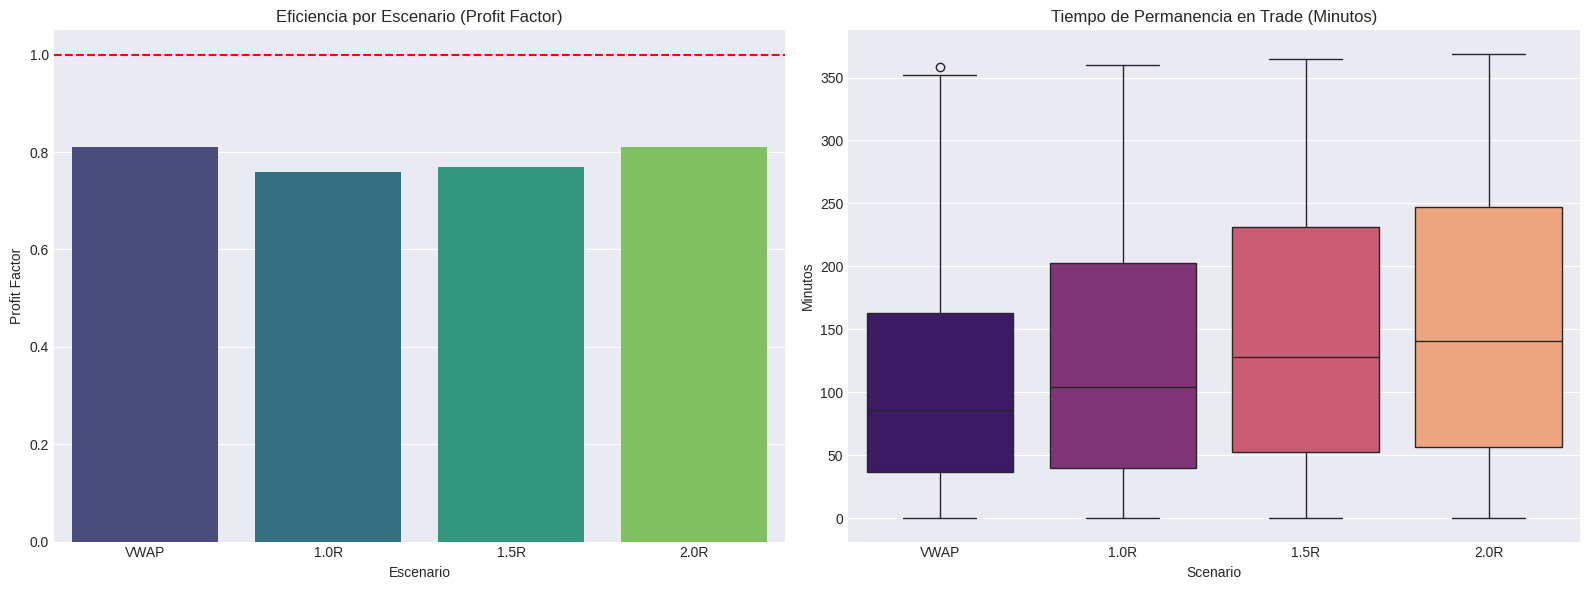

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
SL_ATR_MULT = 0.45  # Basado en MAE promedio + Buffer
R_UNIT = 0.45       # 1R = 0.45 ATR

def run_target_optimization(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    # Filtro Universo
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        
        is_gap_up = day_meta['Gap'] > 0
        trigger_level = open_p - (0.75 * atr) if not is_gap_up else open_p + (0.75 * atr)
        side = 'LONG' if not is_gap_up else 'SHORT'
        
        # Buscar Trigger
        if side == 'LONG':
            trigger_hits = day_data[day_data['Low'] <= trigger_level]
        else:
            trigger_hits = day_data[day_data['High'] >= trigger_level]
            
        if not trigger_hits.empty:
            t_entry = trigger_hits.index[0]
            entry_p = trigger_level
            sl_p = entry_p - (SL_ATR_MULT * atr) if side == 'LONG' else entry_p + (SL_ATR_MULT * atr)
            
            # Definición de Targets
            targets = {
                'VWAP': 'DYNAMIC',
                '1.0R': entry_p + (R_UNIT * atr) if side == 'LONG' else entry_p - (R_UNIT * atr),
                '1.5R': entry_p + (1.5 * R_UNIT * atr) if side == 'LONG' else entry_p - (1.5 * R_UNIT * atr),
                '2.0R': entry_p + (2.0 * R_UNIT * atr) if side == 'LONG' else entry_p - (2.0 * R_UNIT * atr)
            }
            
            post_trigger = day_data.loc[t_entry:]
            
            for label, tp_p in targets.items():
                trade_res = {'Day': day, 'Side': side, 'Scenario': label, 'Entry_Time': t_entry}
                found_exit = False
                
                for t, row in post_trigger.iterrows():
                    current_tp = row['VWAP'] if label == 'VWAP' else tp_p
                    
                    # Chequeo SL
                    if (side == 'LONG' and row['Low'] <= sl_p) or (side == 'SHORT' and row['High'] >= sl_p):
                        trade_res['PnL_R'] = -1.0
                        trade_res['Duration'] = (t - t_entry).seconds / 60
                        trade_res['Type'] = 'SL'
                        found_exit = True
                        break
                    
                    # Chequeo TP
                    if (side == 'LONG' and row['High'] >= current_tp) or (side == 'SHORT' and row['Low'] <= current_tp):
                        # Para VWAP el R es variable, para fijos es el multiplicador
                        if label == 'VWAP':
                            pnl_pts = (row['High'] if side == 'LONG' else row['Low']) - entry_p # Simplificado a touch
                            trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / (R_UNIT * atr)
                        else:
                            trade_res['PnL_R'] = float(label.replace('R',''))
                        
                        trade_res['Duration'] = (t - t_entry).seconds / 60
                        trade_res['Type'] = 'TP'
                        found_exit = True
                        break
                    
                    # Time Exit
                    if t.time() >= pd.Timestamp("15:59").time():
                        pnl_pts = row['Close'] - entry_p
                        trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / (R_UNIT * atr)
                        trade_res['Duration'] = (t - t_entry).seconds / 60
                        trade_res['Type'] = 'TIME'
                        found_exit = True
                        break
                
                # Tracking especial: ¿Tocó R fijo pero nunca VWAP?
                if label != 'VWAP':
                    # Verificamos si en este trade específico el High/Low tocó el TP fijo 
                    # pero el VWAP nunca fue alcanzado antes de las 15:59
                    hit_fixed = trade_res.get('Type') == 'TP'
                    hit_vwap_ever = (post_trigger['High'] >= post_trigger['VWAP']).any() if side == 'LONG' else (post_trigger['Low'] <= post_trigger['VWAP']).any()
                    trade_res['Fixed_But_No_VWAP'] = 1 if (hit_fixed and not hit_vwap_ever) else 0

                all_trades.append(trade_res)

    return pd.DataFrame(all_trades)

def analyze_scenarios(df):
    metrics = []
    scenarios = ['VWAP', '1.0R', '1.5R', '2.0R']
    
    for sc in scenarios:
        sub = df[df['Scenario'] == sc]
        trades = len(sub)
        wr = (sub['PnL_R'] > 0).mean() * 100
        pf = sub[sub['PnL_R'] > 0]['PnL_R'].sum() / abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        exp = sub['PnL_R'].mean()
        
        # Drawdown
        cum_r = sub['PnL_R'].cumsum()
        mdd = (cum_r - cum_r.cummax()).min()
        
        # % Fixed but no VWAP
        no_vwap_pct = sub['Fixed_But_No_VWAP'].mean() * 100 if sc != 'VWAP' else 0
        
        metrics.append({
            'Escenario': sc,
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(exp, 2),
            'Max DD (R)': round(mdd, 2),
            '% Fixed/No VWAP': round(no_vwap_pct, 2)
        })
    
    return pd.DataFrame(metrics)

# --- EJECUCIÓN ---
df_results = run_target_optimization(PATH)
summary_table = analyze_scenarios(df_results)

print("--- MATRIZ COMPARATIVA DE TARGETS ---")
print(summary_table.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparativa Profit Factor
sns.barplot(data=summary_table, x='Escenario', y='Profit Factor', ax=ax1, palette='viridis')
ax1.set_title("Eficiencia por Escenario (Profit Factor)")
ax1.axhline(1.0, color='red', linestyle='--')

# 2. Duración de los Trades
sns.boxplot(data=df_results, x='Scenario', y='Duration', ax=ax2, palette='magma')
ax2.set_title("Tiempo de Permanencia en Trade (Minutos)")
ax2.set_ylabel("Minutos")

plt.tight_layout()
plt.show()

--- REVERSIÓN ACCIÓN DE PRECIO (EMA 9 + SL ESTRUCTURAL) ---
      Target  Win Rate (%)  Profit Factor  Avg SL (ATR)  Esperanza (R)  % Prop vs VWAP
        1.0R         43.34           0.78          0.13          -0.12            0.00
        1.5R         32.60           0.73          0.13          -0.18            0.00
        2.0R         26.44           0.70          0.13          -0.21            0.00
        VWAP         24.06           0.70          0.13          -0.23            0.00
Proporcional         19.28           0.63          0.13          -0.29            0.99


/tmp/ipykernel_4218/960676686.py:182: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_pa, x='Target', y='Esperanza (R)', palette='coolwarm')


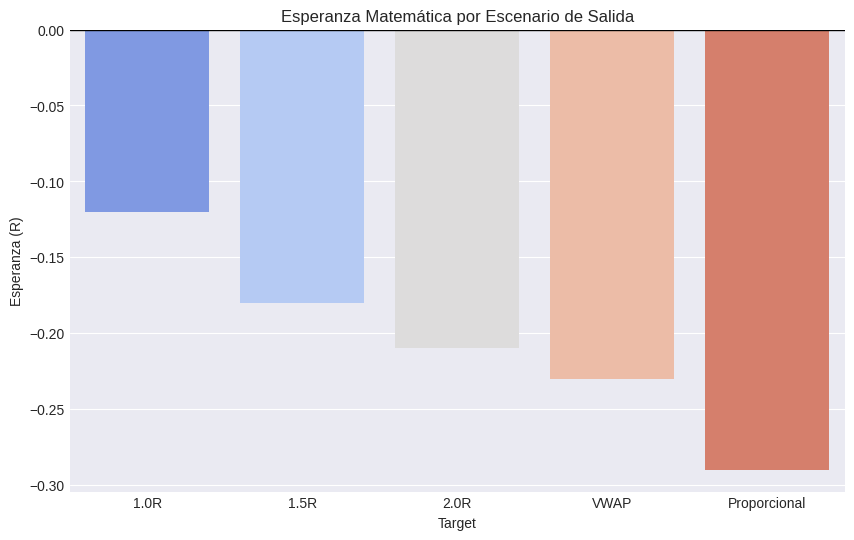

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"

def run_price_action_reversion_study(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Cálculo de EMA 9
    df_rth['EMA9'] = df_rth['Close'].ewm(span=9, adjust=False).mean()
    
    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    # Filtro Universo: |Gap| > 0.25 ATR
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        
        is_gap_up = day_meta['Gap'] > 0
        # Nivel de Alerta: 0.75 ATR contra el Gap
        alert_level = open_p - (0.75 * atr) if not is_gap_up else open_p + (0.75 * atr)
        side = 'LONG' if not is_gap_up else 'SHORT'
        
        # 1. Fase de Alerta: ¿Tocó el 0.75 ATR?
        if side == 'LONG':
            alert_hits = day_data[day_data['Low'] <= alert_level]
        else:
            alert_hits = day_data[day_data['High'] >= alert_level]
            
        if not alert_hits.empty:
            t_alert = alert_hits.index[0]
            post_alert = day_data.loc[t_alert:]
            
            # 2. Búsqueda de Trigger (Cruce EMA 9) y Stop Estructural
            entry_time = None
            entry_p = None
            sl_p = None
            peak_reached = alert_level
            
            for t, row in post_alert.iterrows():
                # Actualizar el pico alcanzado para el Stop Estructural
                if side == 'LONG':
                    peak_reached = min(peak_reached, row['Low'])
                    # Trigger LONG: Cierre por encima de EMA 9
                    if row['Close'] > row['EMA9']:
                        entry_time = t
                        entry_p = row['Close']
                        sl_p = peak_reached
                        break
                else:
                    peak_reached = max(peak_reached, row['High'])
                    # Trigger SHORT: Cierre por debajo de EMA 9
                    if row['Close'] < row['EMA9']:
                        entry_time = t
                        entry_p = row['Close']
                        sl_p = peak_reached
                        break
            
            # Si encontramos entrada antes del cierre
            if entry_time and sl_p != entry_p:
                risk_points = abs(entry_p - sl_p)
                sl_atr_units = risk_points / atr
                
                # Definición de Targets
                targets = {
                    '1.0R': entry_p + risk_points if side == 'LONG' else entry_p - risk_points,
                    '1.5R': entry_p + (1.5 * risk_points) if side == 'LONG' else entry_p - (1.5 * risk_points),
                    '2.0R': entry_p + (2.0 * risk_points) if side == 'LONG' else entry_p - (2.0 * risk_points),
                    'VWAP': 'DYNAMIC',
                    'Proporcional': entry_p + (0.5 * abs(open_p - sl_p)) if side == 'LONG' else entry_p - (0.5 * abs(open_p - sl_p))
                }
                
                post_entry = day_data.loc[entry_time:]
                
                for label, tp_p in targets.items():
                    trade_res = {
                        'Day': day, 'Side': side, 'Scenario': label, 
                        'SL_ATR': sl_atr_units, 'Risk_Points': risk_points
                    }
                    
                    for t_exit, row_exit in post_entry.iterrows():
                        current_tp = row_exit['VWAP'] if label == 'VWAP' else tp_p
                        
                        # Chequeo SL
                        if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                            trade_res['PnL_R'] = -1.0
                            trade_res['Type'] = 'SL'
                            break
                        
                        # Chequeo TP
                        if (side == 'LONG' and row_exit['High'] >= current_tp) or (side == 'SHORT' and row_exit['Low'] <= current_tp):
                            if label == 'VWAP':
                                pnl_pts = (row_exit['High'] if side == 'LONG' else row_exit['Low']) - entry_p
                                trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / risk_points
                            elif label == 'Proporcional':
                                # Calculamos el R efectivo del proporcional
                                pnl_pts = (tp_p - entry_p) if side == 'LONG' else (entry_p - tp_p)
                                trade_res['PnL_R'] = pnl_pts / risk_points
                            else:
                                trade_res['PnL_R'] = float(label.replace('R',''))
                            
                            trade_res['Type'] = 'TP'
                            break
                            
                        # Time Exit
                        if t_exit.time() >= pd.Timestamp("15:59").time():
                            pnl_pts = row_exit['Close'] - entry_p
                            trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / risk_points
                            trade_res['Type'] = 'TIME'
                            break
                    
                    # Tracking Proporcional vs VWAP
                    if label == 'Proporcional':
                        hit_prop = trade_res.get('Type') == 'TP'
                        hit_vwap = (post_entry['High'] >= post_entry['VWAP']).any() if side == 'LONG' else (post_entry['Low'] <= post_entry['VWAP']).any()
                        trade_res['Prop_vs_VWAP'] = 1 if (hit_prop and not hit_vwap) else 0

                    all_trades.append(trade_res)

    return pd.DataFrame(all_trades)

def analyze_pa_scenarios(df):
    metrics = []
    scenarios = ['1.0R', '1.5R', '2.0R', 'VWAP', 'Proporcional']
    
    for sc in scenarios:
        sub = df[df['Scenario'] == sc]
        if sub.empty: continue
        
        wr = (sub['PnL_R'] > 0).mean() * 100
        # Evitar división por cero en PF
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        avg_sl_atr = sub['SL_ATR'].mean()
        expectancy = sub['PnL_R'].mean()
        
        prop_v_vwap = sub['Prop_vs_VWAP'].mean() * 100 if sc == 'Proporcional' else 0
        
        metrics.append({
            'Target': sc,
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Avg SL (ATR)': round(avg_sl_atr, 3),
            'Esperanza (R)': round(expectancy, 2),
            '% Prop vs VWAP': round(prop_v_vwap, 2)
        })
    
    return pd.DataFrame(metrics)

# --- EJECUCIÓN ---
df_pa_results = run_price_action_reversion_study(PATH)
summary_pa = analyze_pa_scenarios(df_pa_results)

print("--- REVERSIÓN ACCIÓN DE PRECIO (EMA 9 + SL ESTRUCTURAL) ---")
print(summary_pa.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_pa, x='Target', y='Esperanza (R)', palette='coolwarm')
plt.title("Esperanza Matemática por Escenario de Salida")
plt.axhline(0, color='black', linewidth=1)
plt.show()

In [ ]:
# REQUERIMIENTO TÉCNICO: CONTINUACIÓN DE MOMENTUM (GAP STRETCH)

## 1. IDENTIFICACIÓN DE LA SEÑAL (IGNICIÓN)
- **Condición A:** |Gap| > 0.25 ATR.
- **Condición B:** El precio cruza el Open y alcanza una distancia de 0.75 ATR desde el Open.
- **Trigger de Entrada:** En el momento exacto en que el precio toca el nivel de 0.75 ATR, entramos a MERCADO a favor de la dirección del movimiento (Long si el gap fue cerrado al alza, Short si fue cerrado a la baja).

## 2. GESTIÓN DE RIESGO (VWAP COMO MURO)
- **Stop Loss (SL):** El valor del VWAP en el momento de la entrada.
- **Riesgo Unitario (1R):** Distancia entre (Punto de Entrada) y (VWAP).
- **Nota:** Si en el momento de la entrada el VWAP está a menos de 0.10 ATR, usar un SL mínimo de 0.20 ATR para evitar ruido.

## 3. MATRIZ DE SALIDAS (TARGETS)
Simular los resultados para los siguientes objetivos fijos:
1. **Target 1.0R**
2. **Target 1.5R**
3. **Target 2.0R**

## 4. MÉTRICAS DE VALIDACIÓN
Para cada escenario de Target, reportar:
- Nº de Trades.
- Win Rate %.
- Profit Factor.
- Esperanza Matemática (R).
- Max Drawdown (R).
- **Distancia Media del SL (ATR):** Para comparar la amplitud del riesgo vs. los tests anteriores.

## 5. REGLA DE TIEMPO
- Cierre forzado a las 15:59 NY si no se ha tocado SL o TP.

--- CONTINUACIÓN DE MOMENTUM (0.75 ATR + VWAP SL) ---
Target  Nº Trades  Win Rate (%)  Profit Factor  Esperanza (R)  Max DD (R)  Avg SL (ATR)
  1.0R        518         55.79           1.44           0.12       -5.18         0.468
  1.5R        518         52.32           1.48           0.14       -7.93         0.468
  2.0R        518         51.16           1.46           0.14       -8.59         0.468


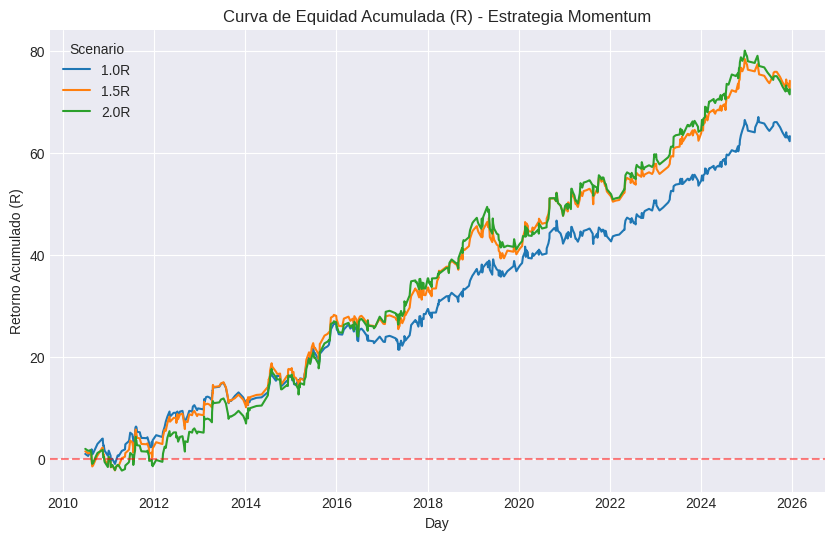

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"

def run_momentum_continuation_study(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    # Filtro Universo: |Gap| > 0.25 ATR
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        
        is_gap_up = day_meta['Gap'] > 0
        # Nivel de Ignición: 0.75 ATR desde el Open cruzando el Gap
        # Si Gap es alcista (>0), el stretch de continuación es alcista (Open + 0.75 ATR)
        # Si Gap es bajista (<0), el stretch de continuación es bajista (Open - 0.75 ATR)
        trigger_level = open_p + (0.75 * atr) if is_gap_up else open_p - (0.75 * atr)
        side = 'LONG' if is_gap_up else 'SHORT'
        
        # 1. Detección de Trigger (Tocar nivel a favor del Momentum)
        if side == 'LONG':
            trigger_hits = day_data[day_data['High'] >= trigger_level]
        else:
            trigger_hits = day_data[day_data['Low'] <= trigger_level]
            
        if not trigger_hits.empty:
            t_entry = trigger_hits.index[0]
            entry_p = trigger_level
            vwap_at_entry = day_data.loc[t_entry, 'VWAP']
            
            # 2. Gestión de Riesgo (VWAP como Muro)
            sl_p = vwap_at_entry
            risk_points = abs(entry_p - sl_p)
            
            # Regla de SL Mínimo: si el riesgo es < 0.10 ATR, usar 0.20 ATR para evitar ruido
            if risk_points < (0.10 * atr):
                risk_points = 0.20 * atr
                sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
            
            sl_atr_units = risk_points / atr
            
            # 3. Simulación de Targets Fijos
            targets = {
                '1.0R': entry_p + risk_points if side == 'LONG' else entry_p - risk_points,
                '1.5R': entry_p + (1.5 * risk_points) if side == 'LONG' else entry_p - (1.5 * risk_points),
                '2.0R': entry_p + (2.0 * risk_points) if side == 'LONG' else entry_p - (2.0 * risk_points)
            }
            
            post_entry = day_data.loc[t_entry:]
            
            for label, tp_p in targets.items():
                trade_res = {
                    'Day': day, 'Side': side, 'Scenario': label, 
                    'SL_ATR': sl_atr_units, 'Risk_Points': risk_points
                }
                
                for t_exit, row_exit in post_entry.iterrows():
                    # Chequeo SL
                    if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                        trade_res['PnL_R'] = -1.0
                        trade_res['Type'] = 'SL'
                        break
                    
                    # Chequeo TP
                    if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                        trade_res['PnL_R'] = float(label.replace('R',''))
                        trade_res['Type'] = 'TP'
                        break
                        
                    # Time Exit (Cierre de sesión)
                    if t_exit.time() >= pd.Timestamp("15:59").time():
                        pnl_pts = row_exit['Close'] - entry_p
                        trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / risk_points
                        trade_res['Type'] = 'TIME'
                        break
                
                all_trades.append(trade_res)

    return pd.DataFrame(all_trades)

def analyze_momentum_results(df):
    metrics = []
    scenarios = ['1.0R', '1.5R', '2.0R']
    
    for sc in scenarios:
        sub = df[df['Scenario'] == sc]
        if sub.empty: continue
        
        total_trades = len(sub)
        wr = (sub['PnL_R'] > 0).mean() * 100
        
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        expectancy = sub['PnL_R'].mean()
        
        # Max Drawdown
        cum_pnl = sub['PnL_R'].cumsum()
        mdd = (cum_pnl - cum_pnl.cummax()).min()
        
        avg_sl_atr = sub['SL_ATR'].mean()
        
        metrics.append({
            'Target': sc,
            'Nº Trades': total_trades,
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(expectancy, 2),
            'Max DD (R)': round(mdd, 2),
            'Avg SL (ATR)': round(avg_sl_atr, 3)
        })
    
    return pd.DataFrame(metrics)

# --- EJECUCIÓN ---
df_mom_results = run_momentum_continuation_study(PATH)
summary_mom = analyze_momentum_results(df_mom_results)

print("--- CONTINUACIÓN DE MOMENTUM (0.75 ATR + VWAP SL) ---")
print(summary_mom.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_mom_results, x='Day', y=df_mom_results.groupby('Scenario')['PnL_R'].cumsum(), hue='Scenario')
plt.title("Curva de Equidad Acumulada (R) - Estrategia Momentum")
plt.ylabel("Retorno Acumulado (R)")
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# REQUERIMIENTO TÉCNICO: SENSIBILIDAD DE ENTRADA (MOMENTUM CONTINUATION)

## 1. PARÁMETROS FIJOS
- **Activo:** NQ
- **Condición Inicial:** |Gap| > 0.25 ATR + Cruce de precio de Apertura (Open).
- **Stop Loss:** Valor de VWAP al momento de entrada (Min 0.20 ATR).
- **Take Profit:** 1.5R fijo.

## 2. VARIABLES DE ENTRADA (ESCENARIOS)
El script debe simular la entrada en 4 niveles de confirmación tras cruzar el Open:
1.  **Entrada 0.00 ATR:** Entrada inmediata al tocar el Open (Breakout puro).
2.  **Entrada 0.25 ATR:** Confirmación ligera.
3.  **Entrada 0.50 ATR:** Confirmación moderada.
4.  **Entrada 0.75 ATR:** Confirmación sólida (Baseline anterior).

## 3. MÉTRICAS COMPARATIVAS
Para cada nivel de entrada, generar la siguiente tabla:
- Nivel de Entrada (ATR).
- Nº de Trades totales.
- Win Rate %.
- Profit Factor.
- Esperanza Matemática (en R).
- Max Drawdown (en R).
- **R Unidad Promedio (en ticks/puntos):** Para ver cuánto arriesgamos en cada escenario.

## 4. ANÁLISIS DE CORRELACIÓN
- ¿Aumenta el Win Rate a medida que exigimos más ATR de confirmación?
- ¿Compensa la reducción de trades (filtro más estricto) la mejora en el Profit Factor?

--- ANÁLISIS DE SENSIBILIDAD DE ENTRADA (NQ) ---
 Entrada (ATR)  Nº Trades  Win Rate (%)  Profit Factor  Esperanza (R)  Max DD (R)  R Unidad (Pts)
          0.00       2119         37.85           0.92          -0.05     -121.96           24.23
          0.25       1378         46.23           1.22           0.11      -23.03           28.69
          0.50        878         52.62           1.39           0.15       -9.25           42.16
          0.75        518         52.32           1.48           0.14       -7.93           54.47


/tmp/ipykernel_4218/1760415842.py:140: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_sens, x='Entrada (ATR)', y='Esperanza (R)', ax=ax1, palette='Blues_d')


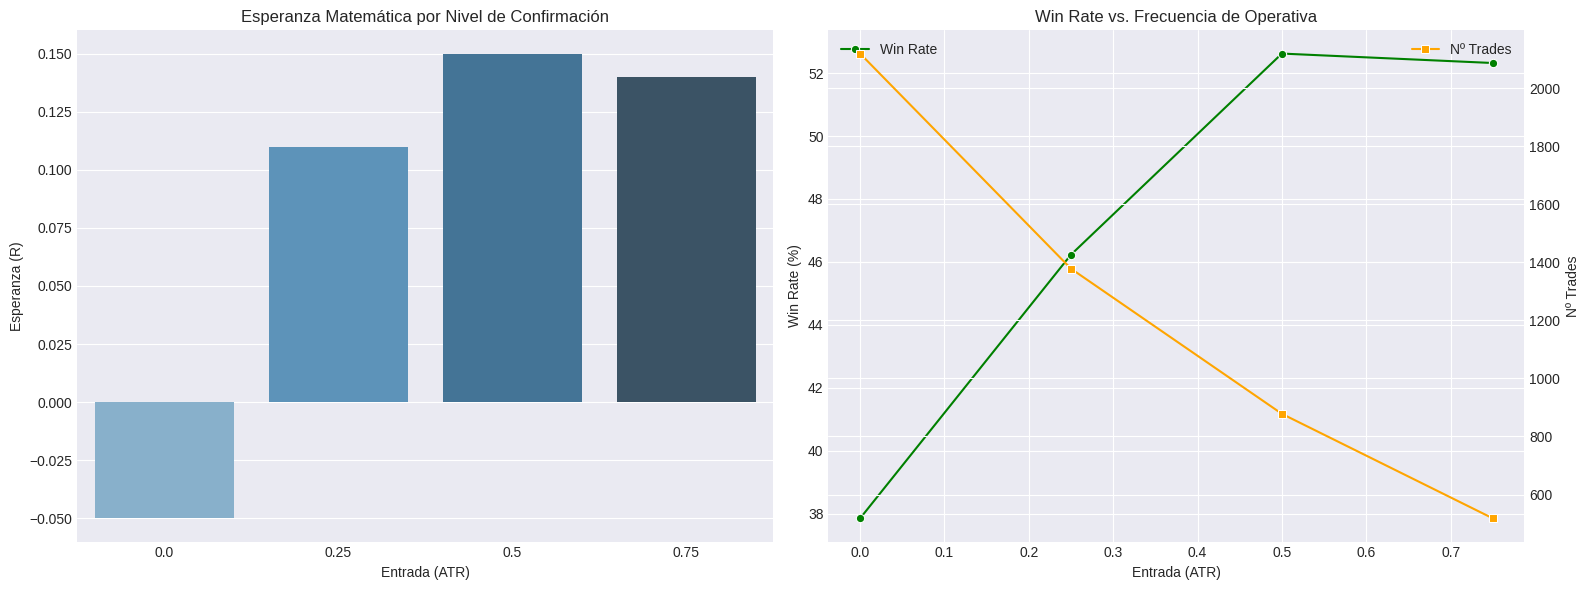

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5  # Take Profit fijo solicitado
MIN_SL_ATR = 0.20 # Stop Loss mínimo para evitar ruido

def run_momentum_sensitivity_study(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    # Filtro Universo: |Gap| > 0.25 ATR
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    # Escenarios de Entrada a testear (en unidades ATR desde el Open)
    atr_triggers = [0.00, 0.25, 0.50, 0.75]
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        is_gap_up = day_meta['Gap'] > 0
        side = 'LONG' if is_gap_up else 'SHORT'

        for trigger_mult in atr_triggers:
            # Definir nivel de entrada según el multiplicador ATR
            if side == 'LONG':
                trigger_level = open_p + (trigger_mult * atr)
                trigger_hits = day_data[day_data['High'] >= trigger_level]
            else:
                trigger_level = open_p - (trigger_mult * atr)
                trigger_hits = day_data[day_data['Low'] <= trigger_level]
            
            if not trigger_hits.empty:
                t_entry = trigger_hits.index[0]
                entry_p = trigger_level
                vwap_at_entry = day_data.loc[t_entry, 'VWAP']
                
                # Gestión de Riesgo (VWAP como Muro)
                risk_points = abs(entry_p - vwap_at_entry)
                
                # Aplicar SL Mínimo
                if risk_points < (0.10 * atr):
                    risk_points = MIN_SL_ATR * atr
                
                sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
                tp_p = entry_p + (FIXED_TP_R * risk_points) if side == 'LONG' else entry_p - (FIXED_TP_R * risk_points)
                
                post_entry = day_data.loc[t_entry:]
                
                trade_res = {
                    'Day': day, 
                    'Entry_ATR': trigger_mult,
                    'Risk_Points': risk_points,
                    'PnL_R': 0.0
                }
                
                for t_exit, row_exit in post_entry.iterrows():
                    # Chequeo SL
                    if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                        trade_res['PnL_R'] = -1.0
                        break
                    
                    # Chequeo TP
                    if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                        trade_res['PnL_R'] = FIXED_TP_R
                        break
                        
                    # Time Exit
                    if t_exit.time() >= pd.Timestamp("15:59").time():
                        pnl_pts = row_exit['Close'] - entry_p
                        trade_res['PnL_R'] = (pnl_pts if side == 'LONG' else -pnl_pts) / risk_points
                        break
                
                all_trades.append(trade_res)

    return pd.DataFrame(all_trades)

def analyze_sensitivity(df):
    metrics = []
    levels = sorted(df['Entry_ATR'].unique())
    
    for lvl in levels:
        sub = df[df['Entry_ATR'] == lvl]
        if sub.empty: continue
        
        wr = (sub['PnL_R'] > 0).mean() * 100
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        exp = sub['PnL_R'].mean()
        
        cum_pnl = sub['PnL_R'].cumsum()
        mdd = (cum_pnl - cum_pnl.cummax()).min()
        
        avg_risk_pts = sub['Risk_Points'].mean()
        
        metrics.append({
            'Entrada (ATR)': lvl,
            'Nº Trades': len(sub),
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(exp, 2),
            'Max DD (R)': round(mdd, 2),
            'R Unidad (Pts)': round(avg_risk_pts, 2)
        })
    
    return pd.DataFrame(metrics)

# --- EJECUCIÓN ---
df_sens = run_momentum_sensitivity_study(PATH)
summary_sens = analyze_sensitivity(df_sens)

print("--- ANÁLISIS DE SENSIBILIDAD DE ENTRADA (NQ) ---")
print(summary_sens.to_string(index=False))

# --- VISUALIZACIONES ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Esperanza vs Nivel de Entrada
sns.barplot(data=summary_sens, x='Entrada (ATR)', y='Esperanza (R)', ax=ax1, palette='Blues_d')
ax1.set_title("Esperanza Matemática por Nivel de Confirmación")

# 2. Relación Win Rate vs Nº de Trades
ax2_twin = ax2.twinx()
sns.lineplot(data=summary_sens, x='Entrada (ATR)', y='Win Rate (%)', ax=ax2, marker='o', color='green', label='Win Rate')
sns.lineplot(data=summary_sens, x='Entrada (ATR)', y='Nº Trades', ax=ax2_twin, marker='s', color='orange', label='Nº Trades')
ax2.set_title("Win Rate vs. Frecuencia de Operativa")
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

# REQUERIMIENTO: FILTRO DE CADUCIDAD DE MOMENTUM (IN-SAMPLE 2010-2020)

## 1. BASE DE TEST
- **Entrada:** 0.50 ATR tras cruce de Open.
- **Stop Loss:** VWAP (Min 0.20 ATR).
- **Take Profit:** 1.5 R.

## 2. VARIABLE A TESTEAR: "TIME TO TRIGGER"
Comparar el rendimiento filtrando por el tiempo transcurrido desde que el precio CRUZA EL OPEN hasta que TOCA EL 0.50 ATR:
- **Grupo 1 (Flash):** < 10 minutos.
- **Grupo 2 (Standard):** < 20 minutos.
- **Grupo 3 (Slow):** < 40 minutos.
- **Grupo 4 (Sin límite):** Baseline actual (878 trades).

## 3. DATA OUT-OF-SAMPLE (BLOQUEO)
- Confirmar que estos resultados pertenecen UNICAMENTE al periodo 2010-2020. No mostrar resultados de 2021-2026 bajo ninguna circunstancia para evitar sesgo de optimización.

## 4. OUTPUT REQUERIDO
Tabla comparativa:
- Ventana de Tiempo.
- Nº de Trades.
- Win Rate %.
- Profit Factor.
- Esperanza (R).

Buscando datos In-Sample: 2010-01-01 a 2020-12-31...

--- TABLA COMPARATIVA: FILTRO DE CADUCIDAD (2010-2020) ---
Ventana de Tiempo  Nº Trades  Win Rate (%)  Profit Factor  Esperanza (R)
     Flash (<10m)         38         55.26           1.78          0.348
  Standard (<20m)        105         46.67           1.29          0.150
      Slow (<40m)        203         47.78           1.34          0.169
       Sin Límite        597         52.60           1.44          0.168


/tmp/ipykernel_4218/4218900641.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_decay, x='Ventana de Tiempo', y='Profit Factor', palette='rocket')


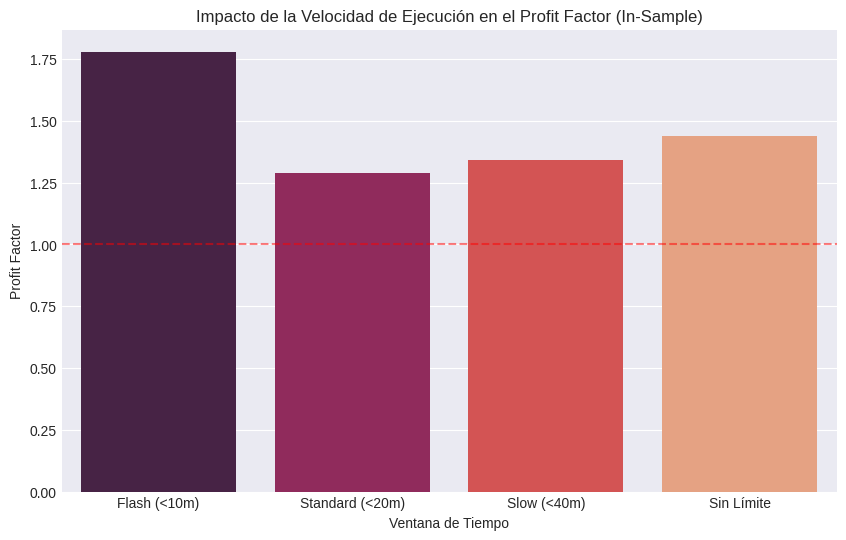

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5      # Take Profit fijo
MIN_SL_ATR = 0.20     # Stop Loss mínimo
TRIGGER_ATR = 0.50    # Nivel de entrada fijo para este test
START_DATE = "2010-01-01"
END_DATE = "2020-12-31" # Límite estricto In-Sample

def run_momentum_decay_study(file_path):
    # 1. Carga y Preparación (Filtrado Temporal In-Sample)
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Restricción In-Sample 2010-2020
    df_rth = df_rth[(df_rth.index >= START_DATE) & (df_rth.index <= END_DATE)]
    
    if df_rth.empty:
        print("Error: No hay datos en el rango 2010-2020.")
        return pd.DataFrame()

    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        is_gap_up = day_meta['Gap'] > 0
        side = 'LONG' if is_gap_up else 'SHORT'

        # 1. Encontrar momento de cruce del Open (T0)
        # Para un Gap Continuation, el precio debe estar del lado del Gap respecto al Open
        if side == 'LONG':
            cross_open_hits = day_data[day_data['High'] >= open_p]
        else:
            cross_open_hits = day_data[day_data['Low'] <= open_p]
            
        if cross_open_hits.empty: continue
        t_open_cross = cross_open_hits.index[0]
        
        # 2. Encontrar momento de Trigger 0.50 ATR (T1)
        trigger_level = open_p + (TRIGGER_ATR * atr) if side == 'LONG' else open_p - (TRIGGER_ATR * atr)
        
        if side == 'LONG':
            trigger_hits = day_data.loc[t_open_cross:][day_data.loc[t_open_cross:]['High'] >= trigger_level]
        else:
            trigger_hits = day_data.loc[t_open_cross:][day_data.loc[t_open_cross:]['Low'] <= trigger_level]
            
        if not trigger_hits.empty:
            t_entry = trigger_hits.index[0]
            
            # Calcular "Time to Trigger" en minutos
            time_to_trigger = (t_entry - t_open_cross).seconds / 60
            
            entry_p = trigger_level
            vwap_at_entry = day_data.loc[t_entry, 'VWAP']
            
            # Gestión de Riesgo
            risk_points = abs(entry_p - vwap_at_entry)
            if risk_points < (0.10 * atr):
                risk_points = MIN_SL_ATR * atr
            
            sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
            tp_p = entry_p + (FIXED_TP_R * risk_points) if side == 'LONG' else entry_p - (FIXED_TP_R * risk_points)
            
            post_entry = day_data.loc[t_entry:]
            pnl_r = 0.0
            
            for t_exit, row_exit in post_entry.iterrows():
                if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                    pnl_r = -1.0
                    break
                if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                    pnl_r = FIXED_TP_R
                    break
                if t_exit.time() >= pd.Timestamp("15:59").time():
                    pts = row_exit['Close'] - entry_p
                    pnl_r = (pts if side == 'LONG' else -pts) / risk_points
                    break
            
            all_trades.append({
                'Day': day,
                'TimeToTrigger': time_to_trigger,
                'PnL_R': pnl_r
            })

    return pd.DataFrame(all_trades)

def analyze_decay_filters(df):
    if df.empty: return "No hay datos para analizar."
    
    # Definición de Grupos
    bins = [0, 10, 20, 40, 999]
    labels = ['Flash (<10m)', 'Standard (<20m)', 'Slow (<40m)', 'Sin Límite']
    
    results = []
    
    for i in range(len(bins)-1):
        if i == 3: # Sin límite (Baseline)
            sub = df
        else:
            sub = df[df['TimeToTrigger'] <= bins[i+1]]
            
        wr = (sub['PnL_R'] > 0).mean() * 100
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        exp = sub['PnL_R'].mean()
        
        results.append({
            'Ventana de Tiempo': labels[i],
            'Nº Trades': len(sub),
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(exp, 3)
        })
        
    return pd.DataFrame(results)

# --- EJECUCIÓN ---
print(f"Buscando datos In-Sample: {START_DATE} a {END_DATE}...")
df_decay = run_momentum_decay_study(PATH)
summary_decay = analyze_decay_filters(df_decay)

print("\n--- TABLA COMPARATIVA: FILTRO DE CADUCIDAD (2010-2020) ---")
print(summary_decay.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_decay, x='Ventana de Tiempo', y='Profit Factor', palette='rocket')
plt.title("Impacto de la Velocidad de Ejecución en el Profit Factor (In-Sample)")
plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)
plt.show()

Analizando Sesión NY In-Sample (2010-2020)...

--- RESULTADOS POR VENTANA HORARIA ---
            Bloque Horario  Nº Trades  Win Rate (%)  Profit Factor  Esperanza (R)  DD Promedio (R)
    Apertura (09:30-10:30)        273         51.28           1.55          0.249            -2.00
Media Mañana (10:31-12:00)        149         54.36           1.50          0.189            -1.47
    Almuerzo (12:01-14:00)         96         52.08           1.22          0.068            -1.82
       Tarde (14:01-15:30)         47         44.68           0.68         -0.093            -4.79


/tmp/ipykernel_4218/4005003495.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_hourly, x='Bloque Horario', y='Esperanza (R)', palette='viridis')


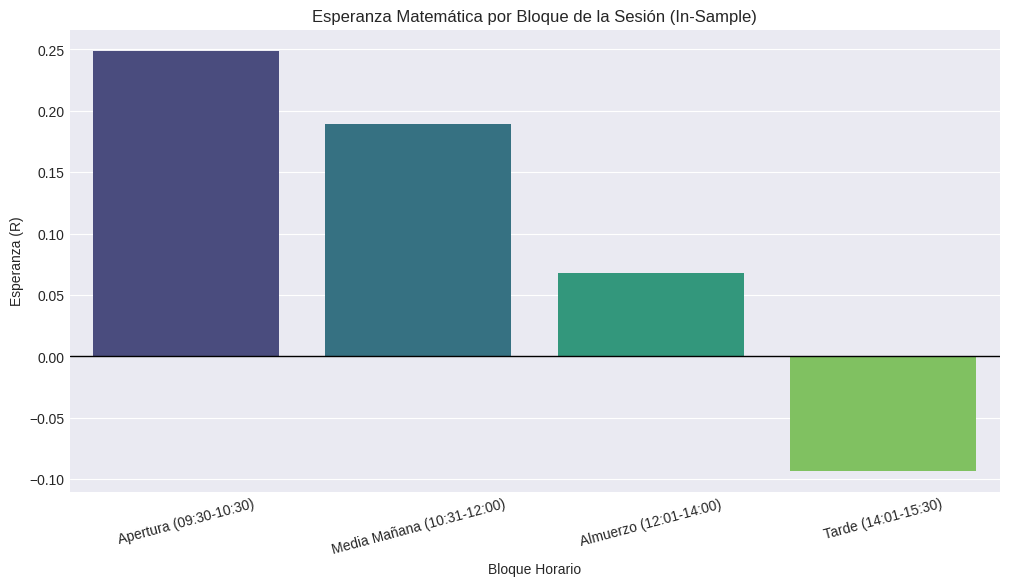

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5      # Take Profit fijo
MIN_SL_ATR = 0.20     # Stop Loss mínimo
TRIGGER_ATR = 0.50    # Nivel de entrada fijo (Confirmación moderada)
START_DATE = "2010-01-01"
END_DATE = "2020-12-31" # Límite estricto In-Sample

def run_hourly_window_study(file_path):
    # 1. Carga y Preparación (Filtrado Temporal In-Sample)
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Restricción In-Sample 2010-2020
    df_rth = df_rth[(df_rth.index >= START_DATE) & (df_rth.index <= END_DATE)]
    
    if df_rth.empty:
        print("Error: No hay datos en el rango 2010-2020.")
        return pd.DataFrame()

    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    
    daily_valid = daily[(daily['Gap'].abs() > 0.25 * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        is_gap_up = day_meta['Gap'] > 0
        side = 'LONG' if is_gap_up else 'SHORT'

        # 1. Punto de cruce del Open
        if side == 'LONG':
            cross_open_hits = day_data[day_data['High'] >= open_p]
        else:
            cross_open_hits = day_data[day_data['Low'] <= open_p]
            
        if cross_open_hits.empty: continue
        t_open_cross = cross_open_hits.index[0]
        
        # 2. Trigger 0.50 ATR
        trigger_level = open_p + (TRIGGER_ATR * atr) if side == 'LONG' else open_p - (TRIGGER_ATR * atr)
        
        if side == 'LONG':
            trigger_hits = day_data.loc[t_open_cross:][day_data.loc[t_open_cross:]['High'] >= trigger_level]
        else:
            trigger_hits = day_data.loc[t_open_cross:][day_data.loc[t_open_cross:]['Low'] <= trigger_level]
            
        if not trigger_hits.empty:
            t_entry = trigger_hits.index[0]
            entry_time = t_entry.time() # Para segmentación horaria
            
            entry_p = trigger_level
            vwap_at_entry = day_data.loc[t_entry, 'VWAP']
            
            # Gestión de Riesgo
            risk_points = abs(entry_p - vwap_at_entry)
            if risk_points < (0.10 * atr):
                risk_points = MIN_SL_ATR * atr
            
            sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
            tp_p = entry_p + (FIXED_TP_R * risk_points) if side == 'LONG' else entry_p - (FIXED_TP_R * risk_points)
            
            post_entry = day_data.loc[t_entry:]
            pnl_r = 0.0
            
            for t_exit, row_exit in post_entry.iterrows():
                if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                    pnl_r = -1.0
                    break
                if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                    pnl_r = FIXED_TP_R
                    break
                if t_exit.time() >= pd.Timestamp("15:59").time():
                    pts = row_exit['Close'] - entry_p
                    pnl_r = (pts if side == 'LONG' else -pts) / risk_points
                    break
            
            all_trades.append({
                'Day': day,
                'Entry_Time': entry_time,
                'PnL_R': pnl_r
            })

    return pd.DataFrame(all_trades)

def segment_by_hour(df):
    if df.empty: return "No hay datos."
    
    # Definición de bloques horarios NY
    def get_block(t):
        if time(9, 30) <= t <= time(10, 30): return "Apertura (09:30-10:30)"
        if time(10, 31) <= t <= time(12, 0): return "Media Mañana (10:31-12:00)"
        if time(12, 1) <= t <= time(14, 0): return "Almuerzo (12:01-14:00)"
        if time(14, 1) <= t <= time(15, 30): return "Tarde (14:01-15:30)"
        return "Cierre/Otros"

    df['Bloque'] = df['Entry_Time'].apply(get_block)
    
    results = []
    bloques = ["Apertura (09:30-10:30)", "Media Mañana (10:31-12:00)", "Almuerzo (12:01-14:00)", "Tarde (14:01-15:30)"]
    
    for b in bloques:
        sub = df[df['Bloque'] == b].copy()
        if sub.empty: continue
        
        wr = (sub['PnL_R'] > 0).mean() * 100
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        # Drawdown promedio (basado en la curva de equidad del bloque)
        sub = sub.sort_values('Day')
        cum_r = sub['PnL_R'].cumsum()
        drawdowns = cum_r - cum_r.cummax()
        avg_dd = drawdowns.mean()
        
        results.append({
            'Bloque Horario': b,
            'Nº Trades': len(sub),
            'Win Rate (%)': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(sub['PnL_R'].mean(), 3),
            'DD Promedio (R)': round(avg_dd, 2)
        })
        
    return pd.DataFrame(results)

# --- EJECUCIÓN ---
print(f"Analizando Sesión NY In-Sample (2010-2020)...")
df_trades = run_hourly_window_study(PATH)
summary_hourly = segment_by_hour(df_trades)

print("\n--- RESULTADOS POR VENTANA HORARIA ---")
print(summary_hourly.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_hourly, x='Bloque Horario', y='Esperanza (R)', palette='viridis')
plt.title("Esperanza Matemática por Bloque de la Sesión (In-Sample)")
plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=15)
plt.show()

# TEST DE SENSIBILIDAD POR TAMAÑO DE GAP (2010-2020)
# Solo Entradas 09:30 - 12:00 NY | TP 1.5R | SL VWAP

## 1. ESCENARIOS DE GAP
Comparar el rendimiento según el tamaño del Gap de apertura:
- **Gap Pequeño:** > 0.15 ATR
- **Gap Estándar:** > 0.25 ATR (Baseline actual)
- **Gap Grande:** > 0.50 ATR

## 2. MÉTRICAS A COMPARAR
Para cada nivel de Gap:
- Nº de Trades.
- Win Rate %.
- Profit Factor.
- Esperanza (R).
- **Distancia Media del Stop (Pts):** Para ver si gaps más grandes implican un VWAP más alejado (más riesgo por trade).

Iniciando Test de Sensibilidad por Tamaño de Gap (In-Sample 2010-2020)...

--- RESULTADOS POR TAMAÑO DE GAP (Solo 09:30-12:00 NY) ---
       Escenario Gap  Nº Trades  Win Rate %  Profit Factor  Esperanza (R)  Dist. Media Stop (Pts)
 Pequeño (>0.15 ATR)        529       51.98           1.51          0.222                   20.49
Estándar (>0.25 ATR)        422       52.37           1.53          0.228                   20.76
  Grande (>0.50 ATR)        229       45.85           1.18          0.088                   20.32


/tmp/ipykernel_4218/1144896864.py:159: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_gap, x='Escenario Gap', y='Esperanza (R)', palette='magma', ax=ax1)
/tmp/ipykernel_4218/1144896864.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_gap, x='Escenario Gap', y='Dist. Media Stop (Pts)', palette='magma', ax=ax2)


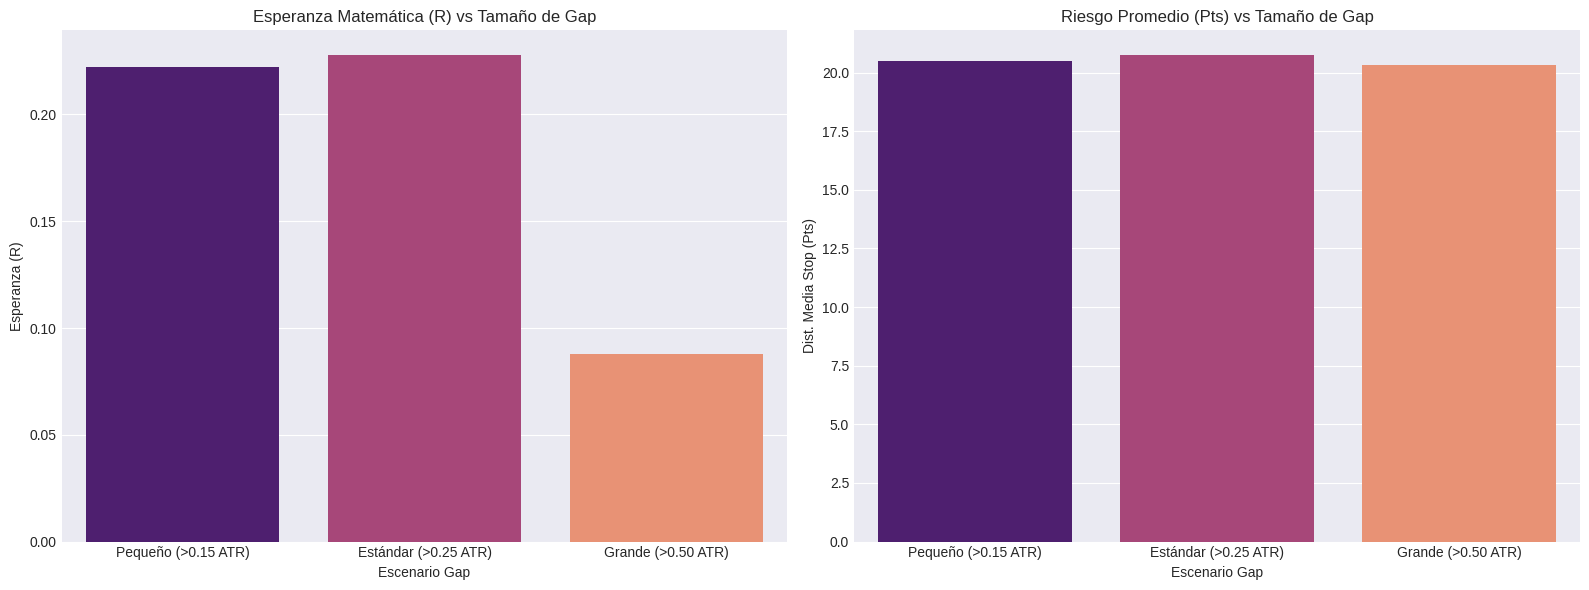

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5      # Take Profit fijo
MIN_SL_ATR = 0.20     # Stop Loss mínimo
TRIGGER_ATR = 0.50    # Confirmación de entrada (0.5 ATR desde Open)
START_DATE = "2010-01-01"
END_DATE = "2020-12-31" # Límite estricto In-Sample

def run_gap_sensitivity_study(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Restricción Temporal In-Sample
    df_rth = df_rth[(df_rth.index >= START_DATE) & (df_rth.index <= END_DATE)]
    
    if df_rth.empty:
        print("Error: No hay datos en el rango seleccionado.")
        return pd.DataFrame()

    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap'] = daily['Open'] - daily['Prev_Close']
    daily['Gap_Abs'] = daily['Gap'].abs()
    
    # Definición de Escenarios de Gap
    gap_scenarios = {
        'Pequeño (>0.15 ATR)': 0.15,
        'Estándar (>0.25 ATR)': 0.25,
        'Grande (>0.50 ATR)': 0.50
    }
    
    all_trades = []
    
    for label, gap_threshold in gap_scenarios.items():
        # Filtrar días según el umbral de Gap actual
        daily_valid = daily[(daily['Gap_Abs'] > gap_threshold * daily['ATR_14']) & (daily['ATR_14'].notna())].copy()
        
        for day in daily_valid.index:
            day_data = df_rth[df_rth.index.date == day].copy()
            day_meta = daily_valid.loc[day]
            atr = day_meta['ATR_14']
            open_p = day_meta['Open']
            
            # Calcular VWAP Dinámico
            day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
            is_gap_up = day_meta['Gap'] > 0
            side = 'LONG' if is_gap_up else 'SHORT'

            # 1. Buscar cruce del Open
            if side == 'LONG':
                cross_open_hits = day_data[day_data['High'] >= open_p]
            else:
                cross_open_hits = day_data[day_data['Low'] <= open_p]
                
            if cross_open_hits.empty: continue
            t_open_cross = cross_open_hits.index[0]
            
            # 2. Buscar Trigger (0.50 ATR)
            trigger_level = open_p + (TRIGGER_ATR * atr) if side == 'LONG' else open_p - (TRIGGER_ATR * atr)
            
            # FILTRO HORARIO: Solo entradas entre 09:30 y 12:00 NY
            if side == 'LONG':
                potential_entries = day_data.loc[t_open_cross:day.strftime('%Y-%m-%d') + ' 12:00:00']
                trigger_hits = potential_entries[potential_entries['High'] >= trigger_level]
            else:
                potential_entries = day_data.loc[t_open_cross:day.strftime('%Y-%m-%d') + ' 12:00:00']
                trigger_hits = potential_entries[potential_entries['Low'] <= trigger_level]
                
            if not trigger_hits.empty:
                t_entry = trigger_hits.index[0]
                entry_p = trigger_level
                vwap_at_entry = day_data.loc[t_entry, 'VWAP']
                
                # Gestión de Riesgo (VWAP)
                risk_points = abs(entry_p - vwap_at_entry)
                if risk_points < (0.10 * atr):
                    risk_points = MIN_SL_ATR * atr
                
                sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
                tp_p = entry_p + (FIXED_TP_R * risk_points) if side == 'LONG' else entry_p - (FIXED_TP_R * risk_points)
                
                post_entry = day_data.loc[t_entry:]
                pnl_r = 0.0
                
                for t_exit, row_exit in post_entry.iterrows():
                    # Stop Loss
                    if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                        pnl_r = -1.0
                        break
                    # Take Profit
                    if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                        pnl_r = FIXED_TP_R
                        break
                    # Cierre de sesión
                    if t_exit.time() >= pd.Timestamp("15:59").time():
                        pts = row_exit['Close'] - entry_p
                        pnl_r = (pts if side == 'LONG' else -pts) / risk_points
                        break
                
                all_trades.append({
                    'Scenario': label,
                    'Day': day,
                    'Risk_Pts': risk_points,
                    'PnL_R': pnl_r
                })

    return pd.DataFrame(all_trades)

def analyze_gap_sensitivity(df):
    if df.empty: return "No hay trades registrados."
    
    results = []
    scenarios = ['Pequeño (>0.15 ATR)', 'Estándar (>0.25 ATR)', 'Grande (>0.50 ATR)']
    
    for sc in scenarios:
        sub = df[df['Scenario'] == sc].copy()
        if sub.empty: continue
        
        wr = (sub['PnL_R'] > 0).mean() * 100
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        results.append({
            'Escenario Gap': sc,
            'Nº Trades': len(sub),
            'Win Rate %': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(sub['PnL_R'].mean(), 3),
            'Dist. Media Stop (Pts)': round(sub['Risk_Pts'].mean(), 2)
        })
        
    return pd.DataFrame(results)

# --- EJECUCIÓN ---
print(f"Iniciando Test de Sensibilidad por Tamaño de Gap (In-Sample 2010-2020)...")
df_gap_results = run_gap_sensitivity_study(PATH)
summary_gap = analyze_gap_sensitivity(df_gap_results)

print("\n--- RESULTADOS POR TAMAÑO DE GAP (Solo 09:30-12:00 NY) ---")
print(summary_gap.to_string(index=False))

# --- VISUALIZACIÓN ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Esperanza vs Gap
sns.barplot(data=summary_gap, x='Escenario Gap', y='Esperanza (R)', palette='magma', ax=ax1)
ax1.set_title("Esperanza Matemática (R) vs Tamaño de Gap")

# Riesgo vs Gap
sns.barplot(data=summary_gap, x='Escenario Gap', y='Dist. Media Stop (Pts)', palette='magma', ax=ax2)
ax2.set_title("Riesgo Promedio (Pts) vs Tamaño de Gap")

plt.tight_layout()
plt.show()

# TEST DE RANGOS DE GAP (BUSCANDO EL TECHO DE MOMENTUM)

## 1. ESCENARIOS DE FILTRO (ATR)
Evaluar el rendimiento limitando el tamaño máximo del Gap:
- **Rango A (Conservador):** 0.15 ATR a 0.40 ATR
- **Rango B (Estándar):** 0.15 ATR a 0.50 ATR
- **Rango C (Amplio):** 0.15 ATR a 0.60 ATR
- **Rango D (Sin Techo):** > 0.15 ATR (Baseline anterior)

## 2. MÉTRICAS DE VALIDACIÓN
- Nº de Trades (Frecuencia operativa).
- Win Rate %.
- Profit Factor (Buscamos > 1.50).
- Max Drawdown (R).

Buscando el Techo de Momentum (In-Sample 2010-2020)...

--- TEST DE RANGOS DE GAP (BUSCANDO EL TECHO) ---
    Rango Gap (ATR)  Nº Trades  Win Rate %  Profit Factor  Esperanza (R)  Max Drawdown (R)
Rango A (0.15-0.40)        232       55.60           1.75          0.299             -6.81
Rango B (0.15-0.50)        300       56.67           1.83          0.323             -6.50
Rango C (0.15-0.60)        369       53.39           1.61          0.256             -9.68
    Rango D (>0.15)        529       51.98           1.51          0.222             -9.20


/tmp/ipykernel_4218/3914636373.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_ranges, x='Rango Gap (ATR)', y='Profit Factor', palette='coolwarm')


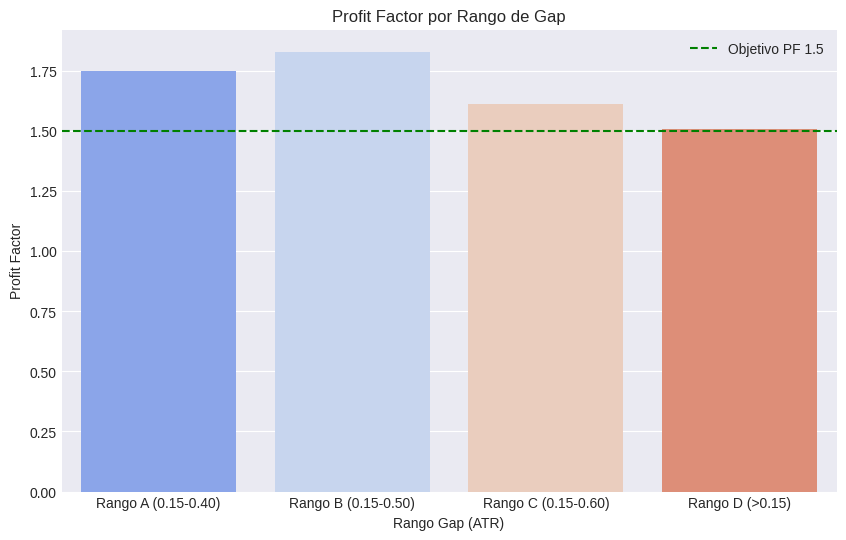

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5      # Take Profit fijo
MIN_SL_ATR = 0.20     # Stop Loss mínimo
TRIGGER_ATR = 0.50    # Confirmación de entrada (0.5 ATR desde Open)
START_DATE = "2010-01-01"
END_DATE = "2020-12-31" # Límite estricto In-Sample

def run_gap_range_study(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Restricción Temporal In-Sample
    df_rth = df_rth[(df_rth.index >= START_DATE) & (df_rth.index <= END_DATE)]
    
    if df_rth.empty:
        print("Error: No hay datos en el rango seleccionado.")
        return pd.DataFrame()

    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap_Abs'] = (daily['Open'] - daily['Prev_Close']).abs()
    daily['Gap_ATR'] = daily['Gap_Abs'] / daily['ATR_14']
    
    # Definición de Rangos de Gap (ATR)
    # Rango: (min, max)
    range_configs = {
        'Rango A (0.15-0.40)': (0.15, 0.40),
        'Rango B (0.15-0.50)': (0.15, 0.50),
        'Rango C (0.15-0.60)': (0.15, 0.60),
        'Rango D (>0.15)': (0.15, 99.0)
    }
    
    all_trades = []
    
    for label, (g_min, g_max) in range_configs.items():
        daily_valid = daily[(daily['Gap_ATR'] >= g_min) & (daily['Gap_ATR'] <= g_max) & (daily['ATR_14'].notna())].copy()
        
        for day in daily_valid.index:
            day_data = df_rth[df_rth.index.date == day].copy()
            day_meta = daily_valid.loc[day]
            atr = day_meta['ATR_14']
            open_p = day_meta['Open']
            
            # Calcular VWAP Dinámico
            day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
            is_gap_up = (day_meta['Open'] - day_meta['Prev_Close']) > 0
            side = 'LONG' if is_gap_up else 'SHORT'

            # 1. Buscar cruce del Open
            if side == 'LONG':
                cross_open_hits = day_data[day_data['High'] >= open_p]
            else:
                cross_open_hits = day_data[day_data['Low'] <= open_p]
                
            if cross_open_hits.empty: continue
            t_open_cross = cross_open_hits.index[0]
            
            # 2. Buscar Trigger (0.50 ATR) limitado a 12:00 NY
            trigger_level = open_p + (TRIGGER_ATR * atr) if side == 'LONG' else open_p - (TRIGGER_ATR * atr)
            
            potential_entries = day_data.loc[t_open_cross:day.strftime('%Y-%m-%d') + ' 12:00:00']
            if side == 'LONG':
                trigger_hits = potential_entries[potential_entries['High'] >= trigger_level]
            else:
                trigger_hits = potential_entries[potential_entries['Low'] <= trigger_level]
                
            if not trigger_hits.empty:
                t_entry = trigger_hits.index[0]
                entry_p = trigger_level
                vwap_at_entry = day_data.loc[t_entry, 'VWAP']
                
                # Gestión de Riesgo (VWAP)
                risk_points = abs(entry_p - vwap_at_entry)
                if risk_points < (0.10 * atr):
                    risk_points = MIN_SL_ATR * atr
                
                sl_p = entry_p - risk_points if side == 'LONG' else entry_p + risk_points
                tp_p = entry_p + (FIXED_TP_R * risk_points) if side == 'LONG' else entry_p - (FIXED_TP_R * risk_points)
                
                post_entry = day_data.loc[t_entry:]
                pnl_r = 0.0
                
                for t_exit, row_exit in post_entry.iterrows():
                    if (side == 'LONG' and row_exit['Low'] <= sl_p) or (side == 'SHORT' and row_exit['High'] >= sl_p):
                        pnl_r = -1.0
                        break
                    if (side == 'LONG' and row_exit['High'] >= tp_p) or (side == 'SHORT' and row_exit['Low'] <= tp_p):
                        pnl_r = FIXED_TP_R
                        break
                    if t_exit.time() >= pd.Timestamp("15:59").time():
                        pts = row_exit['Close'] - entry_p
                        pnl_r = (pts if side == 'LONG' else -pts) / risk_points
                        break
                
                all_trades.append({
                    'Scenario': label,
                    'Day': day,
                    'PnL_R': pnl_r
                })

    return pd.DataFrame(all_trades)

def analyze_gap_ranges(df):
    if df.empty: return "No hay trades."
    
    results = []
    scenarios = ['Rango A (0.15-0.40)', 'Rango B (0.15-0.50)', 'Rango C (0.15-0.60)', 'Rango D (>0.15)']
    
    for sc in scenarios:
        sub = df[df['Scenario'] == sc].copy()
        if sub.empty: continue
        
        sub = sub.sort_values('Day')
        wr = (sub['PnL_R'] > 0).mean() * 100
        pos_pnl = sub[sub['PnL_R'] > 0]['PnL_R'].sum()
        neg_pnl = abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        pf = pos_pnl / neg_pnl if neg_pnl != 0 else np.inf
        
        # Max Drawdown
        cum_r = sub['PnL_R'].cumsum()
        mdd = (cum_r - cum_r.cummax()).min()
        
        results.append({
            'Rango Gap (ATR)': sc,
            'Nº Trades': len(sub),
            'Win Rate %': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(sub['PnL_R'].mean(), 3),
            'Max Drawdown (R)': round(mdd, 2)
        })
        
    return pd.DataFrame(results)

# --- EJECUCIÓN ---
print(f"Buscando el Techo de Momentum (In-Sample 2010-2020)...")
df_results = run_gap_range_study(PATH)
summary_ranges = analyze_gap_ranges(df_results)

print("\n--- TEST DE RANGOS DE GAP (BUSCANDO EL TECHO) ---")
print(summary_ranges.to_string(index=False))

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_ranges, x='Rango Gap (ATR)', y='Profit Factor', palette='coolwarm')
plt.axhline(1.5, color='green', linestyle='--', label='Objetivo PF 1.5')
plt.title("Profit Factor por Rango de Gap")
plt.legend()
plt.show()

Iniciando Auditoría de Ejecución (In-Sample 2010-2020)...

--- RESULTADOS: AUDITORÍA DE EJECUCIÓN ---
             Escenario  Nº Trades  Win Rate %  Profit Factor  Esperanza (R)
     Al Toque (Límite)        529       51.98           1.51          0.222
Cierre 1m (Confirmado)        518       54.05           1.61          0.254


/tmp/ipykernel_4218/1814657179.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_audit, x='Escenario', y='Esperanza (R)', palette='Set2')


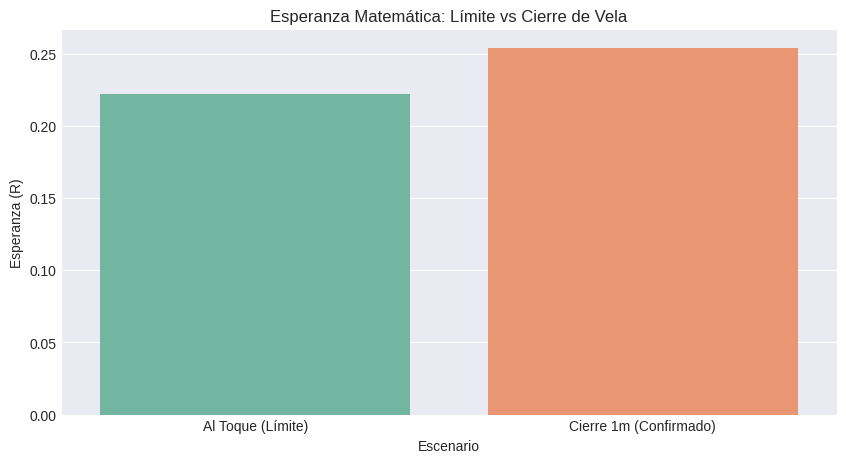

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

# --- CONFIGURACIÓN E INMUTABLES ---
PATH = "/home/quant/data/processed/nq_1m_continuous.parquet"
FIXED_TP_R = 1.5      # Take Profit fijo
MIN_SL_ATR = 0.20     # Stop Loss mínimo
TRIGGER_ATR = 0.50    # Confirmación de entrada (0.5 ATR desde Open)
START_DATE = "2010-01-01"
END_DATE = "2020-12-31" # Límite estricto In-Sample

def run_execution_audit(file_path):
    # 1. Carga y Preparación
    df = pd.read_parquet(file_path)
    df_rth = df.between_time('09:30', '16:00').copy()
    
    # Restricción Temporal In-Sample
    df_rth = df_rth[(df_rth.index >= START_DATE) & (df_rth.index <= END_DATE)]
    
    if df_rth.empty:
        print("Error: No hay datos en el rango seleccionado.")
        return pd.DataFrame()

    # Métricas Diarias RTH
    daily = df_rth.groupby(df_rth.index.date).agg({
        'High': 'max', 'Low': 'min', 'Open': 'first', 'Close': 'last'
    })
    daily['Range'] = daily['High'] - daily['Low']
    daily['ATR_14'] = daily['Range'].rolling(window=14).mean().shift(1)
    daily['Prev_Close'] = daily['Close'].shift(1)
    daily['Gap_Abs'] = (daily['Open'] - daily['Prev_Close']).abs()
    daily['Gap_ATR'] = daily['Gap_Abs'] / daily['ATR_14']
    
    # Filtro Base: Gaps > 0.15 ATR (Baseline identificada)
    daily_valid = daily[(daily['Gap_ATR'] >= 0.15) & (daily['ATR_14'].notna())].copy()
    
    all_trades = []
    
    for day in daily_valid.index:
        day_data = df_rth[df_rth.index.date == day].copy()
        day_meta = daily_valid.loc[day]
        atr = day_meta['ATR_14']
        open_p = day_meta['Open']
        
        # Calcular VWAP Dinámico
        day_data['VWAP'] = (day_data['Close'] * day_data['Volume']).cumsum() / day_data['Volume'].cumsum()
        is_gap_up = (day_meta['Open'] - day_meta['Prev_Close']) > 0
        side = 'LONG' if is_gap_up else 'SHORT'

        # 1. Buscar cruce del Open
        if side == 'LONG':
            cross_open_hits = day_data[day_data['High'] >= open_p]
        else:
            cross_open_hits = day_data[day_data['Low'] <= open_p]
            
        if cross_open_hits.empty: continue
        t_open_cross = cross_open_hits.index[0]
        
        # 2. Identificar vela que cruza el Trigger 0.50 ATR
        trigger_level = open_p + (TRIGGER_ATR * atr) if side == 'LONG' else open_p - (TRIGGER_ATR * atr)
        potential_entries = day_data.loc[t_open_cross:day.strftime('%Y-%m-%d') + ' 12:00:00']
        
        if side == 'LONG':
            trigger_hits = potential_entries[potential_entries['High'] >= trigger_level]
        else:
            trigger_hits = potential_entries[potential_entries['Low'] <= trigger_level]
            
        if not trigger_hits.empty:
            t_trigger_candle = trigger_hits.index[0]
            
            # --- ESCENARIO A: ENTRADA AL TOQUE (ORDEN LÍMITE) ---
            entry_p_a = trigger_level
            vwap_a = day_data.loc[t_trigger_candle, 'VWAP']
            risk_a = max(abs(entry_p_a - vwap_a), MIN_SL_ATR * atr)
            sl_a = entry_p_a - risk_a if side == 'LONG' else entry_p_a + risk_a
            tp_a = entry_p_a + (FIXED_TP_R * risk_a) if side == 'LONG' else entry_p_a - (FIXED_TP_R * risk_a)
            
            # --- ESCENARIO B: CIERRE DE 1 MIN (CONFIRMACIÓN) ---
            # La entrada es al Open de la vela SIGUIENTE a la del trigger
            candle_idx = day_data.index.get_loc(t_trigger_candle)
            if candle_idx + 1 < len(day_data):
                t_entry_b = day_data.index[candle_idx + 1]
                entry_p_b = day_data.iloc[candle_idx + 1]['Open']
                
                # Validar que no haya tocado SL o TP en la vela del trigger (Descarte)
                trigger_row = day_data.loc[t_trigger_candle]
                invalid_b = False
                if side == 'LONG':
                    if trigger_row['Low'] <= sl_a or trigger_row['High'] >= tp_a: invalid_b = True
                else:
                    if trigger_row['High'] >= sl_a or trigger_row['Low'] <= tp_a: invalid_b = True
                
                if not invalid_b:
                    vwap_b = day_data.loc[t_entry_b, 'VWAP']
                    risk_b = max(abs(entry_p_b - vwap_b), MIN_SL_ATR * atr)
                    sl_b = entry_p_b - risk_b if side == 'LONG' else entry_p_b + risk_b
                    tp_b = entry_p_b + (FIXED_TP_R * risk_b) if side == 'LONG' else entry_p_b - (FIXED_TP_R * risk_b)
                else:
                    entry_p_b = None
            else:
                entry_p_b = None

            # Simulación Escenario A
            pnl_a = simulate_trade(day_data.loc[t_trigger_candle:], side, entry_p_a, sl_a, tp_a, risk_a)
            all_trades.append({'Scenario': 'Al Toque (Límite)', 'Day': day, 'PnL_R': pnl_a})
            
            # Simulación Escenario B
            if entry_p_b:
                pnl_b = simulate_trade(day_data.loc[t_entry_b:], side, entry_p_b, sl_b, tp_b, risk_b)
                all_trades.append({'Scenario': 'Cierre 1m (Confirmado)', 'Day': day, 'PnL_R': pnl_b})

    return pd.DataFrame(all_trades)

def simulate_trade(data, side, entry, sl, tp, risk):
    for t, row in data.iterrows():
        if (side == 'LONG' and row['Low'] <= sl) or (side == 'SHORT' and row['High'] >= sl):
            return -1.0
        if (side == 'LONG' and row['High'] >= tp) or (side == 'SHORT' and row['Low'] <= tp):
            return FIXED_TP_R
        if t.time() >= time(15, 59):
            pts = row['Close'] - entry
            return (pts if side == 'LONG' else -pts) / risk
    return 0.0

def analyze_audit(df):
    results = []
    for sc in ['Al Toque (Límite)', 'Cierre 1m (Confirmado)']:
        sub = df[df['Scenario'] == sc]
        wr = (sub['PnL_R'] > 0).mean() * 100
        pf = sub[sub['PnL_R'] > 0]['PnL_R'].sum() / abs(sub[sub['PnL_R'] < 0]['PnL_R'].sum())
        results.append({
            'Escenario': sc,
            'Nº Trades': len(sub),
            'Win Rate %': round(wr, 2),
            'Profit Factor': round(pf, 2),
            'Esperanza (R)': round(sub['PnL_R'].mean(), 3)
        })
    return pd.DataFrame(results)

# --- EJECUCIÓN ---
print("Iniciando Auditoría de Ejecución (In-Sample 2010-2020)...")
df_audit = run_execution_audit(PATH)
summary_audit = analyze_audit(df_audit)

print("\n--- RESULTADOS: AUDITORÍA DE EJECUCIÓN ---")
print(summary_audit.to_string(index=False))

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_audit, x='Escenario', y='Esperanza (R)', palette='Set2')
plt.title("Esperanza Matemática: Límite vs Cierre de Vela")
plt.show()

In [ ]:
//@version=5
strategy("NQ Gap Momentum Strategy", overlay=true, 
     initial_capital=100000, 
     default_qty_type=strategy.cash, 
     currency=currency.USD, 
     slippage=8) // 8 ticks = 2 handles (Slippage para NQ)

// --- PARÁMETROS DE ENTRADA ---
group_risk = "Gestión de Riesgo"
risk_usd   = input.float(3000.0, "Riesgo fijo (USD)", group=group_risk, tooltip="Cantidad a arriesgar por trade")
tp_ratio   = input.float(1.5, "Take Profit Ratio (R)", group=group_risk)

group_time = "Horario NY"
start_time = input.session("0930-1200", "Ventana de Entrada", group=group_time)
exit_time  = input.session("1559-1600", "Cierre Forzoso", group=group_time)

group_gap  = "Configuración Gap (ATR)"
gap_min    = input.float(0.15, "Gap Mínimo", minval=0.0, step=0.05, group=group_gap)
gap_max    = input.float(0.50, "Gap Máximo", minval=0.0, step=0.05, group=group_gap)
trigger_mult = input.float(0.50, "Trigger Mult (ATR)", minval=0.0, step=0.05, group=group_gap)

// --- CÁLCULOS DE VOLATILIDAD (ATR DIARIO) ---
atr_d = request.security(syminfo.tickerid, "D", ta.atr(14)[1], lookahead=barmerge.lookahead_on)

// --- LÓGICA DE TIEMPO Y SESIÓN ---
is_new_day = ta.change(time("D")) != 0
in_window  = time(timeframe.period, start_time, "America/New_York")

// --- CAPTURA DE NIVELES DIARIOS (APERTURA 09:30) ---
var float prev_close = na
var float open_today = na
var float gap_size = na
var bool gap_valid = false
var int time_1200 = na

// Identificación exacta de la vela de las 09:30 NY
is_opening_candle = time(timeframe.period, "0930-0931", "America/New_York")

if is_opening_candle
    prev_close := close[1]
    open_today := open
    gap_size := open_today - prev_close
    gap_valid := math.abs(gap_size) >= (atr_d * gap_min) and math.abs(gap_size) <= (atr_d * gap_max)
    // Calculamos el timestamp de las 12:00 del mismo día de forma dinámica
    time_1200 := timestamp("America/New_York", year, month, dayofmonth, 12, 0, 0)

// --- VWAP ANCLADO (REINICIO 09:30 NY) ---
var float vwap_sum_pv = 0.0
var float vwap_sum_vol = 0.0

bool is_trading_session = not na(time(timeframe.period, "0930-1600", "America/New_York"))
bool is_anchor = is_opening_candle

if is_anchor
    vwap_sum_pv := hlcc4 * volume
    vwap_sum_vol := volume
else if is_trading_session
    vwap_sum_pv := vwap_sum_pv + (hlcc4 * volume)
    vwap_sum_vol := vwap_sum_vol + volume

float current_vwap = vwap_sum_pv / vwap_sum_vol

// --- NIVELES DE ENTRADA (TRIGGER) ---
float long_trigger  = open_today + (atr_d * trigger_mult)
float short_trigger = open_today - (atr_d * trigger_mult)

// --- LÓGICA DE ESTRATEGIA ---
bool can_enter = in_window and gap_valid and strategy.position_size == 0

bool long_condition  = can_enter and gap_size > 0 and close > long_trigger
bool short_condition = can_enter and gap_size < 0 and close < short_trigger

if long_condition
    float entry_p = open[0] 
    float sl_p = current_vwap
    float risk_points = entry_p - sl_p
    
    if risk_points > 0
        float tp_p = entry_p + (risk_points * tp_ratio)
        int qty = math.floor(risk_usd / (risk_points * 20))
        if qty > 0
            strategy.entry("Long Gap", strategy.long, qty=qty)
            strategy.exit("Exit Long", "Long Gap", stop=sl_p, limit=tp_p, comment_loss="SL", comment_profit="TP")

if short_condition
    float entry_p = open[0]
    float sl_p = current_vwap
    float risk_points = sl_p - entry_p
    
    if risk_points > 0
        float tp_p = entry_p - (risk_points * tp_ratio)
        int qty = math.floor(risk_usd / (risk_points * 20))
        if qty > 0
            strategy.entry("Short Gap", strategy.short, qty=qty)
            strategy.exit("Exit Short", "Short Gap", stop=sl_p, limit=tp_p, comment_loss="SL", comment_profit="TP")

if not na(time(timeframe.period, exit_time, "America/New_York"))
    strategy.close_all("Cierre Sesión")

// --- ELEMENTOS VISUALES ---

// LÍNEA VERTICAL DE VALIDACIÓN (09:30 NY)
if is_opening_candle
    line.new(bar_index, low - 100, bar_index, high + 100, color=color.new(color.yellow, 0), width=2, style=line.style_dotted)

// 1. VWAP Anclado
plot(is_trading_session ? current_vwap : na, "VWAP Anclado 09:30", color.new(color.blue, 0), 2, plot.style_line)

// 2. Línea de Trigger (Gatillo)
var line trigger_line = na
if is_anchor
    line.delete(trigger_line)
    color trigger_col = gap_size > 0 ? color.green : color.red
    float trigger_lv = gap_size > 0 ? long_trigger : short_trigger
    if gap_valid
        trigger_line := line.new(bar_index, trigger_lv, bar_index + 10, trigger_lv, 
             extend=extend.right, color=color.new(trigger_col, 50), style=line.style_dashed)

// 3. Recuadro de Gap limitado hasta las 12:00
// Ajuste de lógica: Nos aseguramos de que 'top' sea siempre mayor que 'bottom' para la función box.new
if is_anchor and gap_valid
    color box_col = gap_size > 0 ? color.new(color.green, 85) : color.new(color.red, 85)
    float b_top    = math.max(prev_close, open_today)
    float b_bottom = math.min(prev_close, open_today)
    
    box.new(left=time, top=b_top, right=time_1200, bottom=b_bottom, 
         bgcolor=box_col, border_color=color.new(box_col, 50), xloc=xloc.bar_time)

// Línea de Cierre Previo
plot(is_trading_session and gap_valid ? prev_close : na, "Cierre Previo", color.new(color.gray, 50), 1, plot.style_linebr)

// 4. Etiquetas de información diaria
if is_anchor
    label.new(bar_index, high, "Gap: " + str.tostring(gap_size, "#.##") + " pts\nValidez: " + (gap_valid ? "OK" : "NO"), 
         color=color.new(color.black, 0), textcolor=color.white, style=label.style_label_down)